<a href="https://colab.research.google.com/github/Eikthyrnir/uam-cv-sim-to-real-interpretability/blob/data_mode_configurable/DIMO_detection_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wizja komputerowa, dane syntetyczne i testowanie architektur

**Projekty dla studentów V roku / ostatniego semestru. Realizacja w parach dwuosobowych.**

# **Zasady ogólne**

**Każdy projekt jest realizowany przez dokładnie dwie osoby.** Temat ma prowadzić do kompletnego, mierzalnego eksperymentu z użyciem modeli wizyjnych: klasyfikacji, detekcji, segmentacji, pseudoetykietowania, samonadzorowanego uczenia reprezentacji albo analizy luki domenowej. Projekty mogą mocniej akcentować generowanie danych syntetycznych albo testowanie architektur, ale każdy projekt musi kończyć się wynikami ilościowymi i jakościowymi.

· Każda para musi udostępnić publiczne lub dostępne dla prowadzącego repozytorium GitHub z kodem, konfiguracjami, instrukcją uruchomienia, skryptami przygotowania danych i wynikami eksperymentów.

· Każda para musi przygotować dokument wynikowy, najlepiej w formacie PDF lub Google Docs, opisujący cel, dane, metody, architektury, eksperymenty, wyniki, wizualizacje, błędy i ograniczenia.

· Link do repozytorium oraz link do dokumentu wynikowego muszą zostać wpisane do arkusza Google Sheets: [arkusz projektów](https://docs.google.com/spreadsheets/d/1HeEo42lNxoAGrou7ehcJk4KBIXR4Gv7RgMd3FmzLE0I/edit?usp=sharing).

· W arkuszu powinny znaleźć się co najmniej: numer projektu, imiona i nazwiska studentów, link do repozytorium, link do raportu, link do danych/artefaktów/modeli, krótki opis finalnego wariantu eksperymentu oraz status projektu.

· Zbiory danych wskazane poniżej są publicznie dostępne lub powszechnie używane w badaniach. Przed użyciem należy sprawdzić i respektować licencję konkretnego zbioru, obrazu i adnotacji; nie wszystkie zbiory są stricte CC0/public domain.

# **Minimalny zakres wyników**

· Dla lżejszych projektów klasyfikacyjnych lub segmentacyjnych oczekiwane jest około 15-30 sensownych konfiguracji lub wariantów eksperymentalnych.

· Dla cięższych projektów detekcyjnych oczekiwane jest około 8-15 konfiguracji, ale z pełniejszą analizą kosztu obliczeniowego, błędów i transferu domenowego.

· Każdy projekt musi zawierać punkt odniesienia, warianty porównawcze, tabele metryk, wykresy, wizualizacje wyników, przykłady błędów oraz interpretowalność: Grad-CAM, mapy uwagi, aktywacje, filtry lub osadzenia.

· Raport powinien mieć strukturę krótkiego artykułu: wstęp i pytanie badawcze, przegląd literatury, opis danych, metoda, protokół eksperymentów, wyniki, analiza jakościowa, ograniczenia, wnioski i instrukcja reprodukcji.


## **7\. Co sieci naprawdę uczą się z danych syntetycznych? Aktywacje, filtry i skróty decyzyjne**

**Kierunek:** interpretowalność / testowanie architektur

**Zadanie wizyjne:** klasyfikacja lub detekcja

**Publicznie dostępne zbiory danych:** COCO, Open Images, własny zbiór Blender, RarePlanes

**Pytanie badawcze:** Czy model trenowany na syntetykach uczy się obiektu, czy raczej artefaktów renderingu, tła, tekstur i innych skrótów decyzyjnych?

**Opis projektu:** To projekt diagnostyczny. Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych. Następnie analizuje aktywacje warstw, mapy uwagi, Grad-CAM oraz przypadki błędów. Celem jest wykrycie, kiedy syntetyki tworzą bias tła, bias tekstury lub bias kształtu.

**Modele i metody do przetestowania:**

· ResNet/ConvNeXt dla klasyfikacji

· YOLOv10 lub Faster R-CNN dla detekcji

· ViT/DINOv2 dla analizy uwagi

**Wymagane eksperymenty:**

· porównanie 4-5 reżimów danych

· analiza wrażliwości na zasłanianie fragmentów obrazu: usuwanie tła, tekstury, części obiektu

· UMAP/t-SNE osadzeń cech dla danych rzeczywistych i syntetycznych

· analiza 50 poprawnych i 50 błędnych predykcji

**Wymagane wyniki i analiza:**

· dokładność lub mAP

· co najmniej 50 wizualizacji Grad-CAM / mapy uwagi

· mapy filtrów lub aktywacji wybranych warstw

· ranking najczęstszych skrótów decyzyjnych

· sekcja w raporcie: kiedy syntetyki pomagają, a kiedy szkodzą

**Linki:** [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam); [DINOv2](https://github.com/facebookresearch/dinov2); [COCO](https://cocodataset.org/); [Open Images](https://storage.googleapis.com/openimages/web/index.html); [RarePlanes](https://www.iqt.org/library/the-rareplanes-dataset); [ConvNeXt V2](https://github.com/facebookresearch/ConvNeXt-V2)


In [ ]:
# Set seed for reproducibility
import torch

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [ ]:
import os
from pathlib import Path

PROJECT_DIR = '/content/CV_Project_DIMO'
os.makedirs(PROJECT_DIR, exist_ok=True)

models_dir = os.path.join(PROJECT_DIR, 'models')
os.makedirs(models_dir, exist_ok=True)

dimo_ds_path = Path('/content/dimo_small')

## Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [ ]:
from google.colab import drive

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

In [ ]:
# Where snapshots get pushed on Google Drive (used only by the optional archive cell)
DRIVE_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'
os.makedirs(DRIVE_DIR, exist_ok=True)

## Step 2: Download the Dataset

### Download from Tim's Google Drive (much faster)

In [ ]:
!mkdir /content/DIMO_archives

In [ ]:
# !gdown --id 1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM -O /content/DIMO_archives/dimo.tar

In [ ]:
# !gdown --id 1TyINalV-nfdbbalOzcebp4tH9_K-ibI5 -O /content/DIMO_archives/real_d415.tar

In [ ]:
# !gdown 1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO -O /content/DIMO_archives/dimo_small.tar

In [ ]:
!gdown 1UZghk46xe_9E0ylHc5ONcBYWHsX3Qs6U -O /content/DIMO_archives/DIMO_experiment_subsets.tar

In [ ]:
# Alternative if gdown not working
!cp /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/DIMO_experiment_subsets.tar /content/DIMO_archives/DIMO_experiment_subsets.tar

## Upzip

### 10k Subset of dimo-small

In [ ]:
!mkdir -p /content/dimo_small
!tar -xf /content/DIMO_archives/DIMO_experiment_subsets.tar -C /content/dimo_small --strip-components=1

## Install libs


In [ ]:
!pip install ultralytics==8.4.61
# to disable default ultralitics albumetrations to be consistent with other (non-ultralitics) models training
# Ultralytics only adds the block if albumentations is importable. So uninstall it:
!pip uninstall -y albumentations

In [ ]:
!pip install grad-cam

In [ ]:
# We will use trimesh to easily load the 3D .ply models
!pip install trimesh

In [ ]:
!pip install torchmetrics

In [ ]:
!pip install -q "transformers==4.41.2" "huggingface_hub==0.23.4"

In [ ]:
!pip install tidecv

## Utility functions

In [ ]:
import gc
import torch

def free_vram():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    print(f"allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB")

In [ ]:
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

def filter_predictions(output, score_threshold=0.5):
    "Funkcja filtrowania predykcji"
    boxes = output["boxes"].detach().cpu()
    labels = output["labels"].detach().cpu()
    scores = output["scores"].detach().cpu()

    keep = scores >= score_threshold

    return {
        "boxes": boxes[keep],
        "labels": labels[keep],
        "scores": scores[keep],
    }

def draw_target(image_tensor, true_target, width=2):
    if len(true_target["boxes"]) == 0:
        return image_tensor

    # Convert labels tensor to a list of strings for drawing
    label_texts = [str(label) for label in true_target["labels"].tolist()]

    drawn = draw_bounding_boxes(
        image_tensor,
        boxes=true_target["boxes"],
        labels=label_texts,
        colors="lime",
        width=width,
        font_size=18
    )

    return drawn

def draw_predictions(image_tensor, prediction, width=2):
    if len(prediction["boxes"]) == 0:
        return image_tensor

    label_texts = [
        f"Obj {label}: {score:.2f}"
        for label, score in zip(prediction["labels"].tolist(), prediction["scores"].tolist())
    ]

    drawn = draw_bounding_boxes(
        image_tensor,
        boxes=prediction["boxes"],
        labels=label_texts,
        colors="red",
        width=width,
        font_size=18
    )

    return drawn

In [ ]:
import numpy as np
import trimesh
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Cache for 3D models to speed up projection across multiple images
dimo_models_dir = Path(dimo_ds_path) / "models"
models_cache = {}

def get_model_vertices(obj_id):
    if obj_id not in models_cache:
        model_path = os.path.join(dimo_models_dir, f"obj_{int(obj_id):06d}.ply")
        mesh = trimesh.load(model_path)
        models_cache[obj_id] = mesh.vertices
    return models_cache[obj_id]

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import os
import time
import json


# ===================== TIDE error analysis (shared by CNN + Transformer paths) =====================
# TIDE decomposes detection errors into Cls / Loc / Both / Dupe / Bkg / Miss.
# It is a post-hoc diagnostic: run ONCE on the test set per (model x regime), not every epoch.
from tidecv import TIDE
from tidecv.data import Data

def _xyxy_to_xywh(box):
    "Convert a single xyxy box tensor to COCO [x, y, w, h] (what TIDE expects)."
    x1, y1, x2, y2 = box.tolist()
    return [x1, y1, x2 - x1, y2 - y1]

def build_tide_data(all_preds, all_targs, name):
    """Convert accumulated prediction/target dicts into TIDE Data objects.
    all_preds: list of {'boxes','scores','labels'} (cpu tensors, xyxy) - one dict per image
    all_targs: list of {'boxes','labels'}          (cpu tensors, xyxy) - one dict per image
    Feed ALL detections (no score filtering) so TIDE can attribute background/FP errors.
    """
    gt = Data(f"{name}_gt")
    preds = Data(f"{name}_pred")
    for img_id, (pred, targ) in enumerate(zip(all_preds, all_targs)):
        for box, label in zip(targ['boxes'], targ['labels']):
            gt.add_ground_truth(img_id, int(label), _xyxy_to_xywh(box))
        for box, label, score in zip(pred['boxes'], pred['labels'], pred['scores']):
            preds.add_detection(img_id, int(label), float(score), _xyxy_to_xywh(box))
    return gt, preds

def _tide_error_row(tide, name):
    """Flatten one TIDE run's main + special errors (dAP per type) into a flat dict.
    Main:  Cls / Loc / Both / Dupe / Bkg / Miss.   Special:  FalsePos / FalseNeg.
    Returns {} (never raises) if the installed tidecv exposes a different API."""
    try:
        main = tide.get_main_errors()
        special = tide.get_special_errors()
        run_key = list(main.keys())[0]
        row = dict(main[run_key])
        row.update(special.get(run_key, {}))
        return row
    except Exception as e:
        print(f"  (could not extract TIDE magnitudes for {name}: {e})")
        return {}


def compute_tide(all_preds, all_targs, name, out_dir=None, pos_threshold=0.5):
    """Run TIDE error decomposition, print the summary, save the bar plots AND persist the
    per-type dAP magnitudes to <run_dir>/tide_errors.json so a cross-model TIDE table can be
    rebuilt later (also survives the train-skip / snapshot-restore path).
    Keep pos_threshold fixed (0.5) across all runs so regimes stay comparable.
    Returns the TIDE object - its run state holds the per-error-type dAP numbers for tables.
    """
    gt, preds = build_tide_data(all_preds, all_targs, name)
    tide = TIDE()
    tide.evaluate(gt, preds, pos_threshold=pos_threshold, mode=TIDE.BOX)
    print(f"\n--- TIDE error analysis: {name} ---")
    tide.summarize()

    # Persist the 6 main + 2 special error magnitudes for the Czesc I TIDE comparison table.
    persist_dir = out_dir if out_dir is not None else os.path.join(PROJECT_DIR, 'runs', name)
    os.makedirs(persist_dir, exist_ok=True)
    row = _tide_error_row(tide, name)
    row['run'] = name
    with open(os.path.join(persist_dir, 'tide_errors.json'), 'w') as f:
        json.dump(row, f, indent=2)

    if out_dir is not None:
        tide.plot(out_dir=out_dir)
    return tide

def train_one_epoch(model, optimizer, data_loader, device, epoch, num_epochs):
    model.train()
    epoch_train_loss = 0

    for images, targets in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_train_loss += losses.item()

    return epoch_train_loss / len(data_loader)

def evaluate(model, data_loader, device, desc_prefix="Val", run_tide=False, tide_name="", tide_out_dir=None):
    # 1. Get validation loss (torchvision models must be in .train() mode to return losses)
    model.train()
    epoch_loss = 0
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"{desc_prefix} Loss", leave=False):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_loss += losses.item()
    avg_loss = epoch_loss / max(1, len(data_loader))

    # 2. Get mAP (torchvision models must be in .eval() mode to return predictions)
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    all_preds, all_targs = [], []  # accumulated across batches for the optional TIDE pass
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"{desc_prefix} mAP", leave=False):
            images = list(img.to(device) for img in images)
            outputs = model(images)

            preds = []
            for output in outputs:
                preds.append({
                    'boxes': output['boxes'].cpu(),
                    'scores': output['scores'].cpu(),
                    'labels': output['labels'].cpu()
                })

            targs = []
            for target in targets:
                targs.append({
                    'boxes': target['boxes'].cpu(),
                    'labels': target['labels'].cpu()
                })

            metric.update(preds, targs)
            if run_tide:
                all_preds.extend(preds)
                all_targs.extend(targs)

    mAP_results = metric.compute()

    if run_tide:
        compute_tide(all_preds, all_targs, tide_name, out_dir=tide_out_dir)

    return avg_loss, mAP_results

def run_experiment(model, optimizer, lr_scheduler, train_loader, val_loader, test_loader, run_name, num_epochs=5):
    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    writer_train = SummaryWriter(log_dir=os.path.join(run_dir, 'train'))
    writer_val = SummaryWriter(log_dir=os.path.join(run_dir, 'val'))
    writer_main = SummaryWriter(log_dir=run_dir) # Main writer for HParams

    print(f"\n========== Starting Experiment: {run_name} ==========")
    for epoch in range(num_epochs):
        start_time = time.time()

        # Train
        train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch, num_epochs)
        lr_scheduler.step()

        # Validate
        val_loss, val_map_res = evaluate(model, val_loader, device, desc_prefix=f"Epoch {epoch+1}/{num_epochs} [Val]")

        # Log metrics
        writer_train.add_scalar('Loss/Epoch', train_loss, epoch)
        writer_val.add_scalar('Loss/Epoch', val_loss, epoch)
        writer_val.add_scalar('mAP_50_95/Epoch', val_map_res['map'].item(), epoch)
        writer_val.add_scalar('mAP_50/Epoch', val_map_res['map_50'].item(), epoch)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP: {val_map_res['map'].item():.4f}")

    # Test on independent Test set (+ TIDE error decomposition, once, on the final model)
    print("\n--- Running Independent Test Set Evaluation ---")
    test_loss, test_map_res = evaluate(
        model, test_loader, device, desc_prefix="[Test]",
        run_tide=True, tide_name=run_name, tide_out_dir=run_dir
    )
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test mAP (IoU=0.50:0.95): {test_map_res['map'].item():.4f}")
    print(f"Test mAP@0.50:            {test_map_res['map_50'].item():.4f}")

    # Log final results to the HPARAMS tab in TensorBoard
    hparams = {'dataset_regime': run_name, 'epochs': num_epochs}
    metrics = {
        'hparam/test_loss': test_loss,
        'hparam/test_mAP': test_map_res['map'].item(),
        'hparam/test_mAP_50': test_map_res['map_50'].item()
    }
    writer_main.add_hparams(hparams, metrics)

    writer_train.close()
    writer_val.close()
    writer_main.close()

    return test_map_res

In [ ]:
def train_hf_transformer_epoch(model, optimizer, data_loader, device, epoch, num_epochs):
    model.train()
    epoch_train_loss = 0

    for batch in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        kwargs = {"pixel_values": pixel_values}
        if "pixel_mask" in batch:
            kwargs["pixel_mask"] = batch["pixel_mask"].to(device)

        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
        kwargs["labels"] = labels

        outputs = model(**kwargs)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        # Clip grad norm to avoid exploding gradients in transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()

        epoch_train_loss += loss.item()

    return epoch_train_loss / len(data_loader)

def evaluate_hf_transformer(model, processor, data_loader, device, desc_prefix="Val", run_tide=False, tide_name="", tide_out_dir=None):
    model.eval()
    epoch_loss = 0
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    all_preds, all_targs = [], []  # accumulated across batches for the optional TIDE pass

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"{desc_prefix}", leave=False):
            pixel_values = batch["pixel_values"].to(device)
            kwargs = {"pixel_values": pixel_values}
            if "pixel_mask" in batch:
                kwargs["pixel_mask"] = batch["pixel_mask"].to(device)

            labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]
            kwargs["labels"] = labels

            outputs = model(**kwargs)
            epoch_loss += outputs.loss.item()

            # For Post-processing: we need the target sizes (H, W)
            target_sizes = torch.tensor([p.shape[1:] for p in pixel_values]).to(device)

            # Model outputs relative coordinates, processor converts them to absolute image coordinates
            results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.0)

            preds = []
            for res in results:
                preds.append({
                    'boxes': res['boxes'].cpu(),
                    'scores': res['scores'].cpu(),
                    'labels': res['labels'].cpu()
                })

            targs = []
            for t, size in zip(labels, target_sizes):
                h, w = size
                # HF Ground Truths are normalized [center_x, center_y, width, height]
                # We need to un-normalize and convert to [xmin, ymin, xmax, ymax] for torchmetrics
                boxes = t['boxes']
                unnorm_boxes = boxes * torch.tensor([w, h, w, h], dtype=torch.float32).to(device)
                cx, cy, bw, bh = unnorm_boxes.unbind(-1)
                xmin = cx - 0.5 * bw
                ymin = cy - 0.5 * bh
                xmax = cx + 0.5 * bw
                ymax = cy + 0.5 * bh
                abs_boxes = torch.stack([xmin, ymin, xmax, ymax], dim=-1)

                # Handle key differences in label naming (class_labels vs labels depending on processor)
                cls_key = 'class_labels' if 'class_labels' in t else 'labels'
                targs.append({
                    'boxes': abs_boxes.cpu(),
                    'labels': t[cls_key].cpu()
                })

            metric.update(preds, targs)
            if run_tide:
                all_preds.extend(preds)
                all_targs.extend(targs)

    mAP_results = metric.compute()
    avg_loss = epoch_loss / max(1, len(data_loader))
    if run_tide:
        compute_tide(all_preds, all_targs, tide_name, out_dir=tide_out_dir)
    return avg_loss, mAP_results

def run_hf_transformer_experiment(model, processor, optimizer, train_loader, val_loader, test_loader, run_name, num_epochs=5, lr_scheduler=None):
    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    writer_train = SummaryWriter(log_dir=os.path.join(run_dir, 'train'))
    writer_val = SummaryWriter(log_dir=os.path.join(run_dir, 'val'))
    writer_main = SummaryWriter(log_dir=run_dir)

    print(f"\n========== Starting HF Transformer Experiment: {run_name} ==========")
    for epoch in range(num_epochs):
        start_time = time.time()

        # Train
        train_loss = train_hf_transformer_epoch(model, optimizer, train_loader, device, epoch, num_epochs)

        if lr_scheduler is not None:
            lr_scheduler.step()

        # Validate
        val_loss, val_map_res = evaluate_hf_transformer(model, processor, val_loader, device, desc_prefix=f"Epoch {epoch+1}/{num_epochs} [Val]")

        # Log metrics
        writer_train.add_scalar('Loss/Epoch', train_loss, epoch)
        writer_val.add_scalar('Loss/Epoch', val_loss, epoch)
        writer_val.add_scalar('mAP_50_95/Epoch', val_map_res['map'].item(), epoch)
        writer_val.add_scalar('mAP_50/Epoch', val_map_res['map_50'].item(), epoch)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {time.time() - start_time:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mAP: {val_map_res['map'].item():.4f}")

    # Test on independent Test set
    if test_loader is not None:
        print("\n--- Running Independent Test Set Evaluation ---")
        test_loss, test_map_res = evaluate_hf_transformer(
            model, processor, test_loader, device, desc_prefix="[Test]",
            run_tide=True, tide_name=run_name, tide_out_dir=run_dir
        )
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test mAP (IoU=0.50:0.95): {test_map_res['map'].item():.4f}")
        print(f"Test mAP@0.50:            {test_map_res['map_50'].item():.4f}")

        hparams = {'dataset_regime': run_name, 'epochs': num_epochs}
        metrics = {
            'hparam/test_loss': test_loss,
            'hparam/test_mAP': test_map_res['map'].item(),
            'hparam/test_mAP_50': test_map_res['map_50'].item()
        }
        writer_main.add_hparams(hparams, metrics)

    writer_train.close()
    writer_val.close()
    writer_main.close()

    return test_map_res if test_loader else val_map_res


## Load Dataset using Official DIMO Loader
Instead of parsing JSONs manually, use the provided `dimo_loader.py` to structure the dataset.

In [ ]:
!git clone https://github.com/pderoovere/dimo.git /content/dimo_repo

In [ ]:
import sys
import os
# Ensure the current directory is in the path to import dimo_loader
if '/content' not in sys.path:
    sys.path.append('/content')

from dimo_repo.scripts.dimo_loader import DimoLoader
from pathlib import Path

In [ ]:
dimo_loader = DimoLoader()

dimo_ds = dimo_loader.load(
    dimo_ds_path,
    cameras=[
        "real_d415",
        "real_jaigo",
        "real_l515",
      # exclude real_mvbluefox since this folder contains gray folder for gray images instead of rgb.
      # DimoLoader can't handle this and it's also easier to only train on rgb images
      #  "real_mvbluefox",
        "sim_jaigo"
    ])

## Dataset insights

In [ ]:
import pandas as pd

# Prepare a list to hold all the flattened records
records = []

# Iterate through the top-level keys (cameras and 'models')
for cam_name, scenes in dimo_ds.items():
    if cam_name == 'models':
        continue # Skip the 3D models metadata for the main dataframe

    for scene_list_idx, scene in enumerate(scenes):

        scene_id = scene['id']
        for image_list_idx, img in enumerate(scene['images']):
            img_id = img['id']
            img_path = str(img['path'])
            num_objects = len(img['objects'])

            if not os.path.exists(img['path']):
                continue

            image_data = {
                    'camera': cam_name,
                    'scene_id': scene_id,
                    'scene_list_idx': scene_list_idx,
                    'image_id': img_id,
                    'image_list_idx': image_list_idx,
                    'image_path': img_path,
                    'total_objects_in_image': num_objects
                }
            # Use .get() to safely handle cases where scene_info might be missing
            image_data.update(img.get('scene_info', {}))

            # --------- We probably don't need row per obj, row per img is enough --------
            # for obj in img['objects']:
            #     # Crucial: make a copy so we don't overwrite previous objects from the same image
            #     obj_record = image_data.copy()
            #     obj_record['object_id'] = obj['id']

            #     records.append(obj_record)

            records.append(image_data)

# Create the DataFrame
df_dimo = pd.DataFrame(records)

In [ ]:
import pandas as pd

# Group by the specified columns and count occurrences
# dropna=False ensures we don't drop rows where fields like 'exposure' are NaN (e.g., real images)
grouped_counts = df_dimo.groupby(
    ['light', 'exposure', 'environment_rotation', 'carrier'],
    dropna=False
).size().reset_index(name='count')

# Sort by count descending to see the most common configurations
grouped_counts = grouped_counts.sort_values(by='count', ascending=False)

print(f"Total images: {len(df_dimo)}")
print(f"Total unique combinations: {len(grouped_counts)}")
display(grouped_counts.head(20))

In [ ]:
df_dimo.groupby(
    ['light'],
    dropna=False
).size().reset_index(name='count').sort_values(by='count', ascending=False)

In [ ]:
df_dimo.groupby(
    ['camera', 'total_objects_in_image'],
    dropna=False
).size().reset_index(name='count').sort_values(by='total_objects_in_image', ascending=True)

In [ ]:
df_dimo

## Split dataset into subsets

> Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych



In [ ]:
import pandas as pd

# 1. Tylko dane rzeczywiste (Only real data)
df_real_only = df_dimo[df_dimo['camera'].str.startswith('real')].copy()

# 2. Tylko dane syntetyczne (All synthetic data)
df_sim_all = df_dimo[df_dimo['camera'] == 'sim_jaigo'].copy()

# Helper to identify 'Real-world lighting' in simulation
real_world_lights = ['lightRoomImage_hdr', 'darkRoomImage_hdr']

# 3. Słaba randomizacja syntetyczna (Weak randomization)
# We'll use simulation data with real-world lighting environments (allowing default rotations)
df_sim_weak_dr = df_sim_all[
    df_sim_all['light'].isin(real_world_lights)
].copy()

# 4. Silna randomizacja syntetyczna (Strong randomization)
# Simulation data with random HDRI lighting and random rotations
df_sim_strong_dr = df_sim_all[
    ~df_sim_all['light'].isin(real_world_lights)
].copy()

print("--- Dataset Splits for the Project ---")
print(f"1. Tylko dane rzeczywiste:       {len(df_real_only)} observations")
print(f"2. Tylko dane syntetyczne (all): {len(df_sim_all)} observations")
print(f"3. Słaba randomizacja:           {len(df_sim_weak_dr)} observations")
print(f"4. Silna randomizacja:           {len(df_sim_strong_dr)} observations")
print(f"5. Mieszanka danych (Real+Strong): would be calculated later to ensure 50/50 real/sim data split")


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

N_IMAGES_TO_KEEP = 1_000

regimes = {
    'real_only': df_real_only.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_all': df_sim_all.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_weak_dr': df_sim_weak_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
    'sim_strong_dr': df_sim_strong_dr.sample(n=N_IMAGES_TO_KEEP, random_state=RANDOM_SEED),
}

regimes['mixed'] = pd.concat([
                        df_real_only.sample(n=int(N_IMAGES_TO_KEEP / 2), random_state=RANDOM_SEED),
                        df_sim_all.sample(n=int(N_IMAGES_TO_KEEP / 2), random_state=RANDOM_SEED),
                    ], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)

In [ ]:
# Define a separate test set from real data (to be used consistently across all experiments)
N_TEST_IMAGES = 100

# Ensure no overlap with the existing 'real_only' regime used for train/val
used_real_indices = regimes['real_only'].index
df_real_remaining = df_real_only.drop(used_real_indices)

# Sample for the test set
df_real_test = df_real_remaining.sample(n=N_TEST_IMAGES, random_state=RANDOM_SEED)

## Select data mode

We use
- `real_only` data for Part 1 of research
- different data modes for Part 2 of research

In [ ]:
DATA_MODE = 'real_only' # 'real_only', 'sim_all', 'sim_weak_dr', 'sim_strong_dr', 'mixed'

## Create PyTorch Dataset

Implement a PyTorch Dataset class to load a subset of the DIMO data, returning images, labels and bounding boxes

In [ ]:
import torch
import os
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

class DimoDetectionDataset(Dataset):
    def __init__(self, native_dimo_ds, image_set):
        self.samples = []
        self.target_size = (224, 224)
        # For torchvision detectors, we usually just convert to tensor (values 0-1)
        # Normalization is often handled inside the model (e.g., Faster R-CNN)
        self.transform = transforms.Compose([
            transforms.Resize(self.target_size),
            transforms.ToTensor(),
        ])

        # Iterate over the dataframe rows
        for idx, row in image_set.iterrows():
            cam = row['camera']
            # Use the new explicit list indices to fetch directly
            scene_idx = int(row['scene_list_idx'])
            img_idx = int(row['image_list_idx'])

            # Direct list indexing! Extremely fast O(1) lookup.
            try:
                img_data = native_dimo_ds[cam][scene_idx]['images'][img_idx]
            except (KeyError, IndexError):
                continue

            img_path = img_data['path']

            # Skip if the file is missing from the disk
            if not os.path.exists(img_path):
                continue

            # Original image size (needed to clamp projected boxes to the image bounds)
            with Image.open(img_path) as _im:
                img_w, img_h = _im.size

            K = np.array(img_data['camera']['K']).reshape(3, 3)

            bboxes = []
            labels = []

            for obj in img_data['objects']:
                if 'model_2cam' in obj:
                    obj_id = obj['id']
                    pose = np.array(obj['model_2cam'])
                    R = pose[:3, :3]
                    t = pose[:3, 3].reshape(3, 1)

                    # Project 3D to 2D to get the bounding box
                    vertices = get_model_vertices(obj_id)
                    pts_cam = (R @ vertices.T) + t
                    pts_2d = K @ pts_cam

                    u = pts_2d[0, :] / pts_2d[2, :]
                    v = pts_2d[1, :] / pts_2d[2, :]

                    xmin, xmax = np.min(u), np.max(u)
                    ymin, ymax = np.min(v), np.max(v)

                    # Clamp the projected box to the image. Objects can extend past the frame;
                    # unclamped boxes give out-of-bounds coords that Ultralytics drops as
                    # 'corrupt' and that quietly hurt the torchvision/HF models too.
                    xmin = float(np.clip(xmin, 0, img_w - 1))
                    xmax = float(np.clip(xmax, 0, img_w - 1))
                    ymin = float(np.clip(ymin, 0, img_h - 1))
                    ymax = float(np.clip(ymax, 0, img_h - 1))

                    # Drop degenerate boxes (object essentially outside the frame -> zero area)
                    if xmax - xmin < 1.0 or ymax - ymin < 1.0:
                        continue

                    bboxes.append([xmin, ymin, xmax, ymax])
                    labels.append(obj_id)

            if bboxes:
                self.samples.append({
                    'img_path': img_path,
                    'bboxes': torch.tensor(bboxes, dtype=torch.float32),
                    'labels': torch.tensor(labels, dtype=torch.int64)
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['img_path']).convert('RGB')
        orig_w, orig_h = img.size

        # Resize bounding boxes
        target_w, target_h = self.target_size
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h

        boxes = sample['bboxes'].clone()
        boxes[:, 0] *= scale_x # xmin
        boxes[:, 2] *= scale_x # xmax
        boxes[:, 1] *= scale_y # ymin
        boxes[:, 3] *= scale_y # ymax

        # Transform image
        img_tensor = self.transform(img)

        target = {}
        target['boxes'] = boxes
        target['labels'] = sample['labels']

        return img_tensor, target


def collate_fn(batch):
    # Faster R-CNN expects a tuple of (images, targets) rather than stacked tensors
    # because the number of bounding boxes varies per image.
    return tuple(zip(*batch))

In [ ]:
from torch.utils.data import random_split


test_dataset = DimoDetectionDataset(dimo_ds, df_real_test)

detection_train_dataset = DimoDetectionDataset(dimo_ds, regimes[f"{DATA_MODE}"])

train_size = int(0.8 * len(detection_train_dataset))
val_size = len(detection_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(detection_train_dataset, [train_size, val_size], generator=generator)
print(f"Created Train/Val split: {len(train_dataset)} train, {len(val_dataset)} val samples.")

## Create YOLO-required file structure

YOLO models require the dataset to be organized in folders with .txt label files. Let's install the library and convert our data.

In [ ]:
import os
import shutil
import yaml
from tqdm import tqdm
from PIL import Image

yolo_dir = os.path.join(PROJECT_DIR, 'yolo_dataset')
os.makedirs(f'{yolo_dir}/images/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/train', exist_ok=True)
os.makedirs(f'{yolo_dir}/images/val', exist_ok=True)
os.makedirs(f'{yolo_dir}/labels/val', exist_ok=True)

def convert_to_yolo(dataset, split_name):
    for idx in tqdm(range(len(dataset)), desc=f"Converting {split_name}"):
        orig_idx = dataset.indices[idx]
        sample = dataset.dataset.samples[orig_idx]
        img_path = sample['img_path']

        # Copy image
        ext = os.path.splitext(img_path)[1]
        new_img_name = f"{split_name}_{idx}{ext}"
        shutil.copy(img_path, f'{yolo_dir}/images/{split_name}/{new_img_name}')

        # Get image dimensions for YOLO normalization
        with Image.open(img_path) as img:
            w, h = img.size

        boxes = sample['bboxes']
        labels = sample['labels']
        label_file = f'{yolo_dir}/labels/{split_name}/{split_name}_{idx}.txt'

        # Write bounding boxes in YOLO format: class x_center y_center width height
        with open(label_file, 'w') as f:
            for box, label in zip(boxes, labels):
                xmin, ymin, xmax, ymax = box.tolist()
                x_center = ((xmin + xmax) / 2) / w
                y_center = ((ymin + ymax) / 2) / h
                width = (xmax - xmin) / w
                height = (ymax - ymin) / h

                # Assuming our labels are 1-6, YOLO requires 0-indexed classes
                yolo_label = int(label) - 1
                f.write(f"{yolo_label} {x_center} {y_center} {width} {height}\n")

# Convert train and val datasets
convert_to_yolo(train_dataset, 'train')
convert_to_yolo(val_dataset, 'val')

# Create YAML config file
yaml_content = {
    'path': yolo_dir,
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'obj1', 1: 'obj2', 2: 'obj3', 3: 'obj4', 4: 'obj5', 5: 'obj6'}
}
with open(f'{yolo_dir}/dataset.yaml', 'w') as f:
    yaml.dump(yaml_content, f)

print(f"\nYOLO dataset successfully created at {yolo_dir}")

## Faster R-CNN Models

In [ ]:
import torch.optim as optim
import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader

In [ ]:
BATCH_SIZE = 16

In [ ]:
# Create the PyTorch Dataset and DataLoader
test_loader_det = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [ ]:
# Define train_loader_det and create val_loader_det using the collate_fn from previous cell
train_loader_det = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader_det = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

In [ ]:
# 7 classes: background (0) and objects (1 - 6)
NUM_CLASSES = 7

In [ ]:
def get_fasterrcnn_resnet50_fpn_model(num_classes):
    # Load a pre-trained Faster R-CNN model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [ ]:
## Alternative 1: Faster R-CNN with MobileNetV3 Backbone
# Instead of ResNet50, use lightweight `mobilenet_v3_large_fpn`.

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_mobilenet_detection_model(num_classes):
    # Load a pre-trained Faster R-CNN model with a MobileNetV3 backbone
    model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Część I: Multi-architecture comparison (unified harness)

This section trains **many detector variants on `real_only` data** (short, standardized fine-tuning) and scores every one of them through the **same `torchmetrics` mAP + TIDE** harness on the **same shared real test set** (`test_dataset`). That makes all architectures directly comparable — the analytical baseline of Część I.

**Fairness choices (read before changing anything):**
- **Same test pixels** — YOLO is evaluated on the identical 224×224 images every other model sees.
- **Low confidence at eval (`conf=0.001`)** — mAP needs the full precision–recall curve and TIDE needs low-confidence detections to attribute background / false-positive errors. Do **not** use Ultralytics' default `conf=0.25` here.
- **Augmentation disabled** (mosaic / mixup / flips / HSV off) — augmentation is not an experimental variable in this project, so we standardize it to "none" across all models.
- **Label mapping** — YOLO uses 0-indexed classes; we map predictions back to the `1..6` ground-truth label space.

`PART1_RESULTS` is the shared results table. The YOLO sweep fills it below; the non-YOLO models (Faster R-CNN, DETR, YOLOS) can be appended to the **same** table with `record_result(...)` using the `test_map_res` each `run_experiment` already returns — then the scatter shows all architecture families together.

> Note: the headline Część I scatter is *mAP vs Activation-Box Ratio*. Until that metric is implemented we plot *mAP vs #params* as a stand-in, which already shows the within-family scaling axis (Część I, pytanie 4).


## Utility functions (shared harness, interpretability & model builders)

Functions and classes used by every phase below. Run this block once; nothing here is heavy.

In [ ]:
# If TensorBoard shows no YOLO scalars, Ultralytics' TB integration is off
from ultralytics import settings
settings.update({'tensorboard': True})

# FIX for rtdetr tensorboard integration
import ultralytics.utils.callbacks.tensorboard as _tb
_tb._log_tensorboard_graph = lambda trainer: None   # skip the trace that corrupts RT-DETR; keeps scalar logging

In [ ]:
# ===================== Część I: unified evaluation harness for Ultralytics models =====================
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
from ultralytics import YOLO
import os
import torch
import pandas as pd

# Ultralytics prefers an int GPU index or the string 'cpu'
yolo_device = 0 if torch.cuda.is_available() else 'cpu'

@torch.no_grad()
def evaluate_yolo(yolo_model, eval_dataset, name, out_dir=None, imgsz=224,
                  conf=0.001, iou=0.7, max_det=300, run_tide=True):
    """Score an Ultralytics YOLO / RT-DETR model through the SAME torchmetrics + TIDE
    harness used for the torchvision / HF models, on the SAME shared real test set.

    - Feeds the identical 224x224 pixels every other model sees (apples-to-apples).
    - Uses a very low `conf` so mAP sees the full PR curve and TIDE can attribute
      false-positive / background errors (do NOT use Ultralytics' default conf=0.25).
    - Maps YOLO's 0-indexed classes back to the 1..6 label space used by the GT / metric.
    """
    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    all_preds, all_targs = [], []

    for idx in tqdm(range(len(eval_dataset)), desc=f"{name} [Test mAP]", leave=False):
        img_t, target = eval_dataset[idx]
        # img_t is a float CHW tensor in [0,1]; recover an RGB uint8 PIL image.
        # Passing a PIL image makes Ultralytics treat it as RGB (avoids the BGR numpy bug).
        img_pil = Image.fromarray((img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8))

        res = yolo_model.predict(img_pil, imgsz=imgsz, conf=conf, iou=iou,
                                 max_det=max_det, device=yolo_device, verbose=False)[0]
        b = res.boxes
        pred = {
            'boxes': b.xyxy.cpu(),
            'scores': b.conf.cpu(),
            'labels': b.cls.cpu().long() + 1,   # YOLO 0..5  ->  GT space 1..6
        }
        targ = {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}

        metric.update([pred], [targ])
        all_preds.append(pred)
        all_targs.append(targ)

    mAP_results = metric.compute()
    print(f"[{name}] Test mAP@0.50: {mAP_results['map_50'].item():.4f} | "
          f"mAP@0.50:0.95: {mAP_results['map'].item():.4f}")

    if run_tide:
        compute_tide(all_preds, all_targs, name, out_dir=out_dir)

    return mAP_results


def record_result(results_list, model_name, family, mAP_results, n_params_M=None):
    "Append (or replace) one comparable row keyed by model_name -> idempotent on cell re-run."
    row = {
        'model': model_name,
        'family': family,
        'params_M': n_params_M,
        'mAP_50': float(mAP_results['map_50'].item()),
        'mAP_50_95': float(mAP_results['map'].item()),
    }
    for i, r in enumerate(results_list):
        if r['model'] == model_name:
            results_list[i] = row
            return
    results_list.append(row)

In [ ]:
def yolo_family(stem):
    "Architecture family for the scatter."
    s = stem.lower()
    if s.startswith('rtdetr'):
        return 'Hybrid CNN+Transformer'   # DETR-style: CNN backbone + transformer enc/dec
    if s.startswith(('yolov10', 'yolo11', 'yolo12', 'yolo26')):
        return 'YOLO CNN+attn'            # CNN backbone + self-attention (PSA / C2PSA)
    return 'YOLO CNN'                     # v5 / v8 / v9 pure convolutional

In [ ]:
from ultralytics import RTDETR

def load_detector(weights):
    "Pick the right Ultralytics class: RT-DETR for rtdetr-*, YOLO otherwise."
    return RTDETR(weights) if weights.lower().startswith('rtdetr') else YOLO(weights)

In [ ]:
# ===== Część I: unified interpretability — multi-scale EigenCAM + Activation-Box Ratio =====
import numpy as np
import cv2
import torch

def _eigencam_from_feature(feat):
    """EigenCAM (first principal component) for ONE feature map.
    feat: torch tensor or array of shape (C, Hf, Wf). Returns a normalized (Hf, Wf) map in [0, 1]."""
    if hasattr(feat, 'detach'):
        feat = feat.detach().float().cpu().numpy()
    C, Hf, Wf = feat.shape
    X = feat.reshape(C, -1).T                 # (Hf*Wf, C)
    X = X - X.mean(0)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    cam = (X @ Vt[0]).reshape(Hf, Wf)         # projection onto the 1st principal component
    # PCA sign is arbitrary -> orient so the strongest activation is positive
    if cam.flat[np.argmax(np.abs(cam))] < 0:
        cam = -cam
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def _norm(a):
    a = a - a.min()
    return a / (a.max() + 1e-8)


def eigencam(img_tensor, feature_maps):
    """Generic multi-scale EigenCAM core (architecture-agnostic).

    img_tensor:   (1, 3, H, W) - used only to set the output resolution.
    feature_maps: list of feature maps (C, Hf, Wf), one per scale.

    Returns a dict:
        'scales': per-scale maps resized to HxW, each in [0, 1]
        'mean'  : multi-scale mean-combined map, HxW in [0, 1]
        'max'   : multi-scale max-combined  map, HxW in [0, 1]
    """
    H, W = img_tensor.shape[-2:]
    scales = []
    for f in feature_maps:
        cam = _eigencam_from_feature(f)
        scales.append(cv2.resize(cam, (W, H)))
    stack = np.stack(scales, 0)
    return {
        "scales": scales,
        "mean": _norm(stack.mean(0)),
        "max": _norm(stack.max(0)),
    }


def detector_eigencam(model, img_tensor):
    """Multi-scale EigenCAM for an Ultralytics detector (YOLO v5..v26, RT-DETR).

    Hooks the layers that FEED the detection head (head.f) - the P3/P4/P5 neck outputs -
    so it is architecture-agnostic, then defers to the generic eigencam() core.
    model is a YOLO / RTDETR object already on the same device as img_tensor (1,3,H,W) in [0,1].
    """
    pt = model.model.eval()
    head = pt.model[-1]
    feeds = head.f if isinstance(head.f, (list, tuple)) else [head.f]
    layers = [pt.model[i] for i in feeds]

    bufs = {}

    def _make_hook(idx):
        def _hook(module, inp, out):
            bufs[idx] = out
        return _hook

    handles = [layer.register_forward_hook(_make_hook(k)) for k, layer in enumerate(layers)]
    with torch.no_grad():
        pt(img_tensor)
    for h in handles:
        h.remove()

    feature_maps = [bufs[k][0] for k in range(len(layers))]
    return eigencam(img_tensor, feature_maps)


# ImageNet stats the torchvision detection models normalize with internally
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def frcnn_eigencam(model, img_tensor):
    """Multi-scale EigenCAM for a torchvision Faster R-CNN (FPN backbone).

    Runs the FPN backbone directly on the ImageNet-normalized image and feeds its pyramid
    feature maps to the generic eigencam() core - no hooks needed. model and img_tensor
    (1,3,H,W in [0,1]) must be on the same device.
    """
    model.eval()
    mean = _IMAGENET_MEAN.to(img_tensor.device)
    std = _IMAGENET_STD.to(img_tensor.device)
    x = (img_tensor - mean) / std
    with torch.no_grad():
        feats = model.backbone(x)
    feature_maps = [v[0] for v in feats.values()]
    return eigencam(img_tensor, feature_maps)


def activation_box_ratio(cam, boxes, eps=1e-8):
    """Activation-Box Ratio: fraction of saliency-map energy inside the ground-truth boxes.

    cam:   HxW map (>= 0, normalized to [0, 1]).
    boxes: (N, 4) xyxy in the SAME HxW pixel space as cam (the 224x224 test space here).
    Returns ABR in [0, 1].
    """
    H, W = cam.shape
    mask = np.zeros((H, W), dtype=bool)
    for box in np.asarray(boxes, dtype=float):
        x1 = max(0, int(np.floor(box[0])))
        y1 = max(0, int(np.floor(box[1])))
        x2 = min(W, int(np.ceil(box[2])))
        y2 = min(H, int(np.ceil(box[3])))
        if x2 > x1 and y2 > y1:
            mask[y1:y2, x1:x2] = True
    total = float(cam.sum())
    inside = float(cam[mask].sum())
    return inside / (total + eps)


def test_abr_stats(cam_fn, key="mean"):
    """Per-image Activation-Box Ratio of cam_fn over the shared real test set -> (mean, median, n).

    cam_fn: takes a (1, 3, H, W) image tensor on `device` and returns the dict from eigencam()
    or transformer_attention_cam(). Reusable for any family (Faster R-CNN, YOLO / RT-DETR,
    transformers). Median is the outlier-robust aggregate; n is the number of scored images.
    """
    vals = []
    for idx in range(len(test_dataset)):
        img_t, target = test_dataset[idx]
        if len(target["boxes"]) == 0:
            continue
        cams = cam_fn(img_t.unsqueeze(0).to(device))
        vals.append(activation_box_ratio(cams[key], target["boxes"].numpy()))
    vals = np.asarray(vals, dtype=float)
    return float(vals.mean()), float(np.median(vals)), len(vals)

In [ ]:
# ===== Część I: transformer interpretability — attention-CAM (primary) + EigenCAM (cross-check) =====
# DETR / YOLOS use NATIVE attention as the primary saliency (concept-doc choice), with an
# EigenCAM-on-features cross-check to quantify the method confound vs the CNN families.
# Reuses _norm and eigencam from the interpretability funcs cell (no re-definition).
import math
import numpy as np
import cv2
import torch
from torchvision.transforms.functional import to_pil_image


# Transformer input resolution: match the 224 CNN protocol (fair comparison) AND keep ViT
# self-attention fast. Used for training AND _load_transformer so train/eval sizes agree.
TFM_SIZE = {"shortest_edge": 224, "longest_edge": 224}

def _forward_with_attentions(model, pixel_values):
    """Eager forward of a HF transformer detector returning attentions
    (shared by the attention-CAM and the attention visualizer)."""
    model.eval()
    if hasattr(model.config, '_attn_implementation'):
        model.config._attn_implementation = 'eager'
    with torch.no_grad():
        return model(pixel_values=pixel_values, output_attentions=True, return_dict=True)


def _transformer_query_attention(outputs, model_type, Hp, Wp):
    """Per-query attention maps reshaped to the feature grid (shared by the CAM and the visualizer).
    DETR uses decoder->encoder cross-attention; YOLOS uses DET-token self-attention to the patches.
    Returns (maps, fh, fw) with maps shaped (num_queries, fh, fw)."""
    if model_type == 'detr':
        attn = outputs.cross_attentions[-1].mean(dim=1)[0]          # (num_queries, num_keys)
        fh, fw = math.ceil(Hp / 32), math.ceil(Wp / 32)
        rows = attn[:, :fh * fw]
    else:
        attn = outputs.attentions[-1].mean(dim=1)[0]                # (seq, seq)
        fh, fw = Hp // 16, Wp // 16
        num_q = outputs.logits.shape[1]
        rows = attn[-num_q:, 1:1 + fh * fw]                         # DET tokens -> patch columns
    maps = rows.reshape(rows.shape[0], fh, fw)
    return maps, fh, fw


def transformer_attention_cam(model, pixel_values, model_type, target_hw, topk=3):
    """Last-layer, confidence-weighted attention saliency for a HF transformer detector.

    Aggregates the detection queries' / DET tokens' attention to the spatial positions, weighted
    by each query's max foreground softmax prob (always defined). Returns the same dict shape as
    eigencam(): 'mean' (confidence-weighted), 'max' (over the top-k queries), 'scales' (top-k
    per-query maps), all resized to target_hw=(H,W) and normalized to [0,1].
    """
    outputs = _forward_with_attentions(model, pixel_values)
    conf = outputs.logits.softmax(-1)[0, :, :-1].max(-1).values
    Hp, Wp = pixel_values.shape[-2:]
    maps, _, _ = _transformer_query_attention(outputs, model_type, Hp, Wp)
    maps = maps.detach().float().cpu().numpy()                      # (Q, fh, fw)

    w = conf.detach().float().cpu().numpy()
    w = w / (w.sum() + 1e-8)
    weighted = (maps * w[:, None, None]).sum(0)
    top = np.argsort(-w)[:topk]
    top_maps = maps[top]
    H, W = int(target_hw[0]), int(target_hw[1])

    def _resize_norm(a):
        return _norm(cv2.resize(a, (W, H)))

    return {
        'mean': _resize_norm(weighted),
        'max': _resize_norm(np.maximum.reduce(list(top_maps))),
        'scales': [_resize_norm(m) for m in top_maps],
    }


def transformer_eigencam(model, pixel_values, model_type, target_hw):
    """EigenCAM cross-check for a transformer (feature-energy saliency, same method as the CNNs).
    DETR  -> encoder_last_hidden_state reshaped to the H/32 x W/32 grid.
    YOLOS -> last hidden state's patch tokens reshaped to the H/16 x W/16 grid.
    Delegates the PCA + resize to the shared eigencam() core.
    """
    model.eval()
    Hp, Wp = pixel_values.shape[-2:]
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, output_hidden_states=True, return_dict=True)

    if model_type == 'detr':
        fh, fw = math.ceil(Hp / 32), math.ceil(Wp / 32)
        feat = outputs.encoder_last_hidden_state[0][:fh * fw]
    else:
        fh, fw = Hp // 16, Wp // 16
        feat = outputs.hidden_states[-1][0][1:1 + fh * fw]

    feat = feat.reshape(fh, fw, -1).permute(2, 0, 1)               # (D, fh, fw)
    dummy = torch.zeros(1, 3, int(target_hw[0]), int(target_hw[1]))
    return eigencam(dummy, [feat])

# ---- shared transformer model/processor factory (single source of truth) ----
# Reused by the DETR/YOLOS training cells, the checkpoint-reload cells, and _load_transformer
# below, so the "from_pretrained with our 7-class head + eager attention" logic lives in ONE place.
TFM_BASE = {
    "detr": "facebook/detr-resnet-50",
    "yolos": "hustvl/yolos-small",
}


def _transformer_id_maps():
    """1..6 object label space (+ background) shared by every transformer detector here."""
    id2label = {i: f"obj{i}" for i in range(1, NUM_CLASSES)}
    id2label[0] = "background"
    label2id = {v: k for k, v in id2label.items()}
    return id2label, label2id


def build_transformer_processor(model_type):
    """HF image processor for 'detr' / 'yolos', pinned to the shared 224 protocol (TFM_SIZE)."""
    if model_type == "yolos":
        from transformers import YolosImageProcessor
        return YolosImageProcessor.from_pretrained(TFM_BASE["yolos"], size=TFM_SIZE)
    from transformers import DetrImageProcessor
    return DetrImageProcessor.from_pretrained(TFM_BASE["detr"], size=TFM_SIZE)


def build_transformer_model(model_type):
    """Fresh HF detector for 'detr' / 'yolos' with our 7-class head and eager attention.
    eager is required so output_attentions returns real weights for the attention-CAM / ABR."""
    id2label, label2id = _transformer_id_maps()
    kwargs = dict(num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id,
                  ignore_mismatched_sizes=True, attn_implementation="eager")
    if model_type == "yolos":
        from transformers import YolosForObjectDetection
        return YolosForObjectDetection.from_pretrained(TFM_BASE["yolos"], **kwargs)
    from transformers import DetrForObjectDetection
    return DetrForObjectDetection.from_pretrained(TFM_BASE["detr"], revision="no_timm", **kwargs)


def _load_transformer(run):
    """Load a transformer run from transformer_runs/<run>/best.pt -> (model, processor, model_type)."""
    ckpt = os.path.join(PROJECT_DIR, 'transformer_runs', run, 'best.pt')
    if not os.path.exists(ckpt):
        return None, None, None
    model_type = 'yolos' if 'yolos' in run else 'detr'
    processor = build_transformer_processor(model_type)
    model = build_transformer_model(model_type)
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state['model_state_dict'])
    model.to(device).eval()
    return model, processor, model_type


def _transformer_fns(model, processor, model_type):
    """Build (predict_fn, cam_fn, cam_fn_xcheck) that take 224-space tensors, run the HF processor
    internally, and return boxes / maps in the 224 box space."""
    def _pv(img_chw):
        pil = to_pil_image(img_chw.detach().cpu())
        enc = processor(images=pil, return_tensors='pt')
        return enc['pixel_values'].to(device)

    def predict_fn(img_t):
        pv = _pv(img_t)
        with torch.no_grad():
            out = model(pixel_values=pv)
        th = img_t.shape[-2:]
        sizes = torch.tensor([[int(th[0]), int(th[1])]]).to(device)
        res = processor.post_process_object_detection(out, target_sizes=sizes, threshold=0.0)[0]
        return {'boxes': res['boxes'].cpu(), 'scores': res['scores'].cpu(), 'labels': res['labels'].cpu()}

    def cam_fn(img_dev):
        return transformer_attention_cam(model, _pv(img_dev[0]), model_type, target_hw=img_dev.shape[-2:])

    def cam_fn_xcheck(img_dev):
        return transformer_eigencam(model, _pv(img_dev[0]), model_type, target_hw=img_dev.shape[-2:])

    return predict_fn, cam_fn, cam_fn_xcheck

In [ ]:
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision



def _load_ckpt(path):
    # the run-dir name carries the family, so 'rtdetr' appears in the path for RT-DETR runs
    if 'rtdetr' in path.lower():
        return RTDETR(path)
    return YOLO(path)


def _resolve_part1_model(run):
    """Load a Część I run and return (model, predict_fn, cam_fn), or (None, None, None) if missing.

    Handles both Ultralytics runs (yolo_runs/<run>/weights/best.pt) and Faster R-CNN runs
    (frcnn_runs/<run>/best.pt), exposing a uniform interface:
        predict_fn(img_t) -> {'boxes','scores','labels'} (xyxy cpu tensors, labels 1..6)
        cam_fn(img_dev)   -> the eigencam() dict for this model
    """

    transformer_ckpt = os.path.join(PROJECT_DIR, 'transformer_runs', run, 'best.pt')
    if os.path.exists(transformer_ckpt):
        model, processor, model_type = _load_transformer(run)
        predict_fn, cam_fn, _ = _transformer_fns(model, processor, model_type)
        return model, predict_fn, cam_fn

    yolo_ckpt = os.path.join(PROJECT_DIR, 'yolo_runs', run, 'weights', 'best.pt')
    frcnn_ckpt = os.path.join(PROJECT_DIR, 'frcnn_runs', run, 'best.pt')

    if os.path.exists(yolo_ckpt):
        m = _load_ckpt(yolo_ckpt)
        m.model.to(device)

        def predict_fn(img_t):
            img_pil = to_pil_image((img_t * 255).to(torch.uint8))
            res = m.predict(img_pil, imgsz=img_t.shape[-1], conf=0.001, iou=0.7,
                            max_det=300, device=device, verbose=False)[0]
            b = res.boxes
            return {
                'boxes': b.xyxy.cpu(),
                'scores': b.conf.cpu(),
                'labels': b.cls.cpu().long() + 1,   # YOLO 0..5 -> GT space 1..6
            }

        def cam_fn(img_dev):
            return detector_eigencam(m, img_dev)

        return m, predict_fn, cam_fn

    if os.path.exists(frcnn_ckpt):
        ckpt = torch.load(frcnn_ckpt, map_location=device)
        if 'resnet50' in run:
            getter = get_fasterrcnn_resnet50_fpn_model
        else:
            getter = get_mobilenet_detection_model
        m = getter(ckpt['num_classes']).to(device)
        m.load_state_dict(ckpt['model_state_dict'])
        m.roi_heads.score_thresh = 0.001   # low conf so per-image mAP sees the full PR curve
        m.eval()

        def predict_fn(img_t):
            with torch.no_grad():
                out = m([img_t.to(device)])[0]
            return {
                'boxes': out['boxes'].cpu(),
                'scores': out['scores'].cpu(),
                'labels': out['labels'].cpu(),   # torchvision Faster R-CNN already returns 1..6
            }

        def cam_fn(img_dev):
            return frcnn_eigencam(m, img_dev)

        return m, predict_fn, cam_fn

    return None, None, None


def _tp_fp_fn(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_thr=0.5):
    """Greedy per-image matching (same class + IoU>=thr, highest score first)."""
    n_gt, n_pred = len(gt_boxes), len(pred_boxes)
    if n_pred == 0:
        return 0, 0, n_gt
    if n_gt == 0:
        return 0, n_pred, 0
    order = torch.argsort(pred_scores, descending=True)
    pb, pl = pred_boxes[order], pred_labels[order]
    ious = box_iou(pb, gt_boxes)
    matched, tp = set(), 0
    for p in range(n_pred):
        best_g, best_iou = -1, iou_thr
        for g in range(n_gt):
            if g in matched or int(pl[p]) != int(gt_labels[g]):
                continue
            if float(ious[p, g]) >= best_iou:
                best_iou, best_g = float(ious[p, g]), g
        if best_g >= 0:
            matched.add(best_g)
            tp += 1
    return tp, n_pred - tp, n_gt - len(matched)


def show_cam_grid(runs, sample_idx=0, draw_thr=0.5, iou_thr=0.5, alpha=0.5):
    """One row per model (YOLO / RT-DETR / Faster R-CNN):
       left  = image with ground-truth (thick lime) + predicted (thin red) boxes,
               titled with per-image mAP@.5 and TP / FP / FN counts (at draw_thr, iou_thr)
       right = EigenCAM overlays: mean, max, and each per-scale map, ABR in the title.
    Reuses the notebook's filter_predictions / draw_target / draw_predictions utilities and
    resolves each run to the right backend via _resolve_part1_model.
    """
    img_t, target = test_dataset[sample_idx]
    img_dev = img_t.unsqueeze(0).to(device)
    img_u8 = (img_t * 255).to(torch.uint8)
    rgb = np.clip(img_t.permute(1, 2, 0).numpy(), 0, 1)
    gt_np = target['boxes'].numpy()
    gt_t = {'boxes': target['boxes'], 'labels': target['labels']}

    # ---- pass 1: gather drawn image + metrics + CAMs for each model ----
    panels = []
    for run in runs:
        model, predict_fn, cam_fn = _resolve_part1_model(run)
        if model is None:
            panels.append((run, None, None, None))
            continue

        pred_all = predict_fn(img_t)
        pred = filter_predictions(pred_all, score_threshold=draw_thr)   # for drawing + TP/FP/FN

        # per-image mAP@.5 (uses all detections), and TP/FP/FN at the display threshold
        mp = MeanAveragePrecision(box_format='xyxy')
        mp.update([pred_all], [gt_t])
        map50 = float(mp.compute()['map_50'])
        tp, fp, fn = _tp_fp_fn(pred['boxes'], pred['labels'], pred['scores'],
                               gt_t['boxes'], gt_t['labels'], iou_thr=iou_thr)

        left = draw_target(img_u8, target, width=3)     # ground truth: thick lime
        left = draw_predictions(left, pred, width=1)    # predictions: thin red
        cams = cam_fn(img_dev)
        panels.append((run, to_pil_image(left), (map50, tp, fp, fn), cams))

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ---- pass 2: plot the grid (all models) ----
    n_scales = max((len(c['scales']) for *_, c in panels if c), default=3)
    ncols = 3 + n_scales                              # left + mean + max + per-scale maps
    fig, axes = plt.subplots(len(panels), ncols, figsize=(2.8 * ncols, 2.8 * len(panels)))
    axes = np.atleast_2d(axes)

    for r, (run, left_img, stats, cams) in enumerate(panels):
        name = run.replace('part1_', '').replace(f'_{DATA_MODE}', '')
        for c in range(ncols):
            axes[r, c].axis('off')
        if cams is None:
            axes[r, 0].set_title(f'{name}\n(checkpoint missing)', fontsize=8)
            continue

        map50, tp, fp, fn = stats
        axes[r, 0].imshow(left_img)
        axes[r, 0].set_title(f'{name}\nmAP@.5={map50:.2f} | TP={tp} FP={fp} FN={fn}', fontsize=8)
        for c, key in zip((1, 2), ('mean', 'max')):
            abr = activation_box_ratio(cams[key], gt_np)
            axes[r, c].imshow(rgb)
            axes[r, c].imshow(cams[key], cmap='jet', alpha=alpha)
            axes[r, c].set_title(f'EigenCAM {key}  ABR={abr:.2f}', fontsize=8)
        for c, sc in enumerate(cams['scales']):
            axes[r, 3 + c].imshow(rgb)
            axes[r, 3 + c].imshow(sc, cmap='jet', alpha=alpha)
            axes[r, 3 + c].set_title(f'scale {c}', fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from torchvision.transforms.functional import to_pil_image

# --- Helper Functions ---
def get_ground_truth_dict(target, w, h):
    """Converts normalized YOLO ground truth boxes back to absolute pixel coordinates."""
    boxes = target['boxes']
    unnorm_boxes = boxes * torch.tensor([w, h, w, h], dtype=torch.float32)
    cx, cy, bw, bh = unnorm_boxes.unbind(-1)
    xmin = cx - 0.5 * bw
    ymin = cy - 0.5 * bh
    xmax = cx + 0.5 * bw
    ymax = cy + 0.5 * bh
    abs_boxes = torch.stack([xmin, ymin, xmax, ymax], dim=-1)

    cls_key = 'class_labels' if 'class_labels' in target else 'labels'
    return {
        "boxes": abs_boxes.cpu(),
        "labels": target[cls_key].cpu()
    }

def format_image_for_drawing(pixel_values):
    """Formats the raw tensor image for matplotlib and torchvision utilities."""
    img_plot = np.transpose(pixel_values.cpu().numpy()[0], (1, 2, 0))
    img_plot = (img_plot - img_plot.min()) / (img_plot.max() - img_plot.min())

    img_uint8 = (img_plot * 255).astype(np.uint8)
    img_tensor_uint8 = torch.from_numpy(img_uint8).permute(2, 0, 1)
    return img_plot, img_tensor_uint8

def plot_yolos_attentions(img_display, img_plot, attention_mean, queries_kept, num_queries, feature_map_h, feature_map_w, w, h):
    """Plots the original image along with the attention maps for the kept DET tokens."""
    num_boxes_to_show = min(len(queries_kept), 5)
    fig, axes = plt.subplots(1, num_boxes_to_show + 1, figsize=(16, 5))
    if num_boxes_to_show == 1:
        axes = [axes]

    axes[0].imshow(to_pil_image(img_display))
    axes[0].set_title("Original Image with BBoxes")
    axes[0].axis("off")

    for idx, query_idx in enumerate(queries_kept[:num_boxes_to_show]):
        # Row corresponding to the specific [DET] token's attention to all other tokens
        det_token_idx = -num_queries + query_idx.item()

        # Columns corresponding to the image patches
        patch_start_idx = 1
        patch_end_idx = 1 + feature_map_h * feature_map_w

        attn_map = attention_mean[det_token_idx, patch_start_idx:patch_end_idx].reshape(feature_map_h, feature_map_w).cpu().numpy()
        attn_map_resized = cv2.resize(attn_map, (w, h))

        ax = axes[idx + 1]
        ax.imshow(img_plot)
        ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        ax.set_title(f"DET Token {query_idx.item()} Attention")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def visualize_transformer_attentions(model, processor, dataset, sample_idx, device, model_type='yolos', conf_threshold=0.5):
    """Visualize native attention maps for HF transformer detectors (DETR and YOLOS).
    Uses the shared _forward_with_attentions / _transformer_query_attention helpers."""
    pixel_values, target = dataset[sample_idx]
    pixel_values = pixel_values.unsqueeze(0).to(device)
    outputs = _forward_with_attentions(model, pixel_values)

    # Find predictions above our confidence threshold
    probas = outputs.logits.softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > conf_threshold
    queries_kept = keep.nonzero().squeeze(-1)

    if len(queries_kept) == 0:
        print(f"No objects detected with confidence > {conf_threshold} in this sample.")
        return

    # Setup image for drawing
    h, w = pixel_values.shape[-2:]
    img_plot, img_tensor_uint8 = format_image_for_drawing(pixel_values)

    # Post-process predictions to absolute coordinates
    target_sizes = torch.tensor([[h, w]]).to(device)
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=conf_threshold)[0]

    true_target_for_draw = get_ground_truth_dict(target, w, h)
    pred_for_draw = {
        "boxes": results["boxes"].cpu(),
        "labels": results["labels"].cpu(),
        "scores": results["scores"].cpu()
    }

    # Draw using our utility functions
    img_display = draw_target(img_tensor_uint8, true_target_for_draw)
    img_display = draw_predictions(img_display, pred_for_draw)

    num_boxes_to_show = min(len(queries_kept), 5)

    # 1. Plot the original image with bounding boxes separately (larger)
    plt.figure(figsize=(10, 8))
    plt.imshow(to_pil_image(img_display))
    plt.title("Original Image with BBoxes")
    plt.axis("off")
    plt.show()

    # 2. Plot the attention maps in a separate row
    fig, axes = plt.subplots(1, num_boxes_to_show, figsize=(4 * num_boxes_to_show, 4))
    if num_boxes_to_show == 1:
        axes = [axes]

    # Shared per-query attention extraction, then a single plotting loop
    maps, _, _ = _transformer_query_attention(outputs, model_type, h, w)
    title_prefix = "DET Token" if model_type == 'yolos' else "Query"

    for idx, query_idx in enumerate(queries_kept[:num_boxes_to_show]):
        attn_map = maps[query_idx.item()].cpu().numpy()
        attn_map_resized = cv2.resize(attn_map, (w, h))
        ax = axes[idx]
        ax.imshow(img_plot)
        ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        ax.set_title(f"{title_prefix} {query_idx.item()} Attention")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# ===== Część I: transformer data plumbing (shared by DETR + YOLOS training AND attention viz) =====
# DETRDataset wraps our DimoDetectionDataset into the HF COCO-style format. Defined once here so the
# class, both processors, both collate fns and the shared real test sets are available to BOTH the
# training cells (Phase 1, Option B) and the checkpoint-driven attention display (Phase 3) -
# regardless of whether you trained in-session or restored the Drive snapshot.
from PIL import Image
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

processor = build_transformer_processor('detr')
yolos_processor = build_transformer_processor('yolos')


class DETRDataset(DimoDetectionDataset):  # inherits the 3D->2D bbox projection from our dataset
    def __init__(self, native_dimo_ds, image_set, processor):
        super().__init__(native_dimo_ds, image_set)
        self.processor = processor

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample['img_path']).convert("RGB")

        annotations = {'image_id': idx, 'annotations': []}
        for box, label in zip(sample['bboxes'], sample['labels']):
            xmin, ymin, xmax, ymax = box.tolist()
            annotations['annotations'].append({
                'bbox': [xmin, ymin, xmax - xmin, ymax - ymin],
                'category_id': label.item(),
                'area': (xmax - xmin) * (ymax - ymin),
                'iscrowd': 0,
            })

        encoding = self.processor(images=image, annotations=annotations, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze()  # remove batch dim
        target = encoding["labels"][0]
        return pixel_values, target


def detr_collate_fn(batch):
    pixel_values = [item[0] for item in batch]
    encoding = processor.pad(pixel_values, return_tensors="pt")
    labels = [item[1] for item in batch]
    return {'pixel_values': encoding['pixel_values'], 'pixel_mask': encoding['pixel_mask'], 'labels': labels}


def yolos_collate_fn(batch):
    # YOLOS has no pixel_mask: pad the variable-size tensors to the per-batch max instead.
    pixel_values = [item[0] for item in batch]
    max_h = max(p.shape[1] for p in pixel_values)
    max_w = max(p.shape[2] for p in pixel_values)
    padded = []
    for p in pixel_values:
        pad_w = max_w - p.shape[2]
        pad_h = max_h - p.shape[1]
        padded.append(torch.nn.functional.pad(p, (0, pad_w, 0, pad_h)))
    pixel_values = torch.stack(padded)
    labels = [item[1] for item in batch]
    return {'pixel_values': pixel_values, 'labels': labels}


# Shared real test set in HF format (reused for test-set eval AND the attention-map display)
detr_test_dataset = DETRDataset(dimo_ds, df_real_test, processor)
yolos_test_dataset = DETRDataset(dimo_ds, df_real_test, yolos_processor)


## Część I — Phase 1: obtain all models

Get a trained checkpoint for every architecture, either by **restoring the Drive snapshot (Option A, fast)** *or* **training from scratch (Option B, slow)**. Both paths populate `PART1_RESULTS` and the on-disk `yolo_runs/`, `frcnn_runs/`, `transformer_runs/` checkpoints that Phases 2–3 read. Run **one** option.

### Option A — restore checkpoints + results from the Drive snapshot (skip training)

In [ ]:
# !gdown 1btddcdDGNtcA6HlMJEr-NA92tfMbXfPp -O /content/CV_Project_DIMO_snapshot.tar
!gdown 1nSzMrHFuqvGVc38dD2lFewx85caz3rTU -O /content/CV_Project_DIMO_snapshot.tar

In [ ]:
# Alternative if gdown not workingr
!cp /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/project_snapshot_20260611_143055.tar /content/CV_Project_DIMO_snapshot.tar

In [ ]:
!tar -xf /content/CV_Project_DIMO_snapshot.tar -C /content/

In [ ]:
# ===== Skip-training: repopulate in-memory results from the downloaded snapshot =====
# The snapshot restores on-disk artifacts (checkpoints + CSVs), but PART1_RESULTS / df_part1 /
# df_abr are Python objects the training cells build. Reload them here so the visualizations work
# without re-running training. (You still need the data-prep cells above so test_dataset exists.)
import os
import pandas as pd

results_csv = os.path.join(PROJECT_DIR, 'part1_results.csv')
if os.path.exists(results_csv):
    PART1_RESULTS = pd.read_csv(results_csv).to_dict('records')
    print(f"loaded PART1_RESULTS: {len(PART1_RESULTS)} models from part1_results.csv")
else:
    print(f"!! {results_csv} not found - was it in the snapshot? (re-archive after the df_part1 cell ran)")

# Optional: load the precomputed ABR table so you can skip the (few-minute) ABR recompute.
# Alternatively, re-run the ABR-table cell to recompute it from the downloaded checkpoints.
abr_csv = os.path.join(PROJECT_DIR, 'part1_abr.csv')
if os.path.exists(abr_csv):
    df_abr = pd.read_csv(abr_csv)
    print(f"loaded df_abr: {len(df_abr)} models from part1_abr.csv")
else:
    print("part1_abr.csv not found - run the ABR-table cell to compute it from the checkpoints")

### Option B — train all architectures from scratch (slow)

Run the four blocks below in order. `record_result` is idempotent, so re-running a block just refreshes that model's row in `PART1_RESULTS`.

In [ ]:
# ---- Edit this list to control the architecture sweep (kept moderate for Colab time) ----
# Despite the name this list may include non-YOLO Ultralytics detectors (e.g. RT-DETR).
PART1_YOLO_WEIGHTS = [
    'yolov5nu.pt', 'yolov5su.pt', 'yolov5mu.pt', 'yolov5xu.pt',  # YOLOv5  (pure CNN, anchor-free 'u' variants)
    'yolov8n.pt',  'yolov8s.pt',  'yolov8m.pt',  'yolov8x.pt',   # YOLOv8  (pure CNN)
    'yolov9t.pt',  'yolov9s.pt',  'yolov9m.pt',  'yolov9e.pt',   # YOLOv9  (pure CNN, PGI / GELAN)
    'yolov10n.pt', 'yolov10s.pt', 'yolov10m.pt', 'yolov10x.pt',  # YOLOv10 (CNN + PSA attention, NMS-free)
    'yolo11n.pt',  'yolo11s.pt',  'yolo11m.pt',  'yolo11x.pt',   # YOLO11  (CNN + C2PSA attention)
    'yolo26n.pt',  'yolo26s.pt',  'yolo26m.pt',  'yolo26x.pt',   # YOLO26  (newest, NMS-free end-to-end)
    'rtdetr-l.pt', 'rtdetr-x.pt'                                 # RT-DETR (hybrid CNN + transformer enc/dec)
]

PART1_EPOCHS = 20
PART1_IMGSZ  = 224
PART1_BATCH  = 32

In [ ]:
PART1_RESULTS = []

In [ ]:
yolo_yaml = os.path.join(PROJECT_DIR, 'yolo_dataset', 'dataset.yaml')

# Augmentation is NOT an experimental variable -> turn Ultralytics' defaults off so the
# training protocol is identical (no augmentation) for every model.
NO_AUG = dict(
    mosaic=0.0, close_mosaic=0, mixup=0.0, copy_paste=0.0,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.0,
)

for weights in PART1_YOLO_WEIGHTS:
    stem = weights.replace('.pt', '')
    run_name = f"part1_{stem}_{DATA_MODE}"
    print(f"\n========== Część I: training {stem} on {DATA_MODE} ==========")

    # Skip already trained models to allow smooth resuming after a crash
    if any(res['model'] == stem for res in PART1_RESULTS):
        print(f"Skipping {stem}, already trained and evaluated.")
        continue

    ymodel = load_detector(weights)
    ymodel.train(
        data=yolo_yaml, epochs=PART1_EPOCHS, imgsz=PART1_IMGSZ, batch=PART1_BATCH,
        device=yolo_device, project=os.path.join(PROJECT_DIR, 'yolo_runs'),
        name=run_name, exist_ok=True, pretrained=True,
        seed=RANDOM_SEED, deterministic=True, verbose=False,
        **NO_AUG,
    )

    run_dir = os.path.join(PROJECT_DIR, 'runs', run_name)
    mAP = evaluate_yolo(ymodel, test_dataset, run_name, out_dir=run_dir)
    n_params_M = sum(p.numel() for p in ymodel.model.parameters()) / 1e6
    record_result(PART1_RESULTS, stem, yolo_family(stem), mAP, n_params_M)

    del ymodel
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


#### Faster R-CNN (two-stage CNN)

In [ ]:
# ===== Część I: Faster R-CNN (two-stage CNN) -> same PART1_RESULTS table + FPN-EigenCAM ABR =====
# Trains both Faster R-CNN variants on {DATA_MODE} through the SAME run_experiment (mAP + TIDE on the
# shared real test set), records them into PART1_RESULTS, and adds an FPN-based Activation-Box Ratio.
import os
import torch
import torch.optim as optim
import pandas as pd

PART1_FRCNN = {
    "fasterrcnn_resnet50_fpn": get_fasterrcnn_resnet50_fpn_model,
    "fasterrcnn_mobilenet_v3_large_fpn": get_mobilenet_detection_model,
}
FRCNN_EPOCHS = 20   # keep roughly in sync with PART1_EPOCHS


for name, getter in PART1_FRCNN.items():
    run_name = f"part1_{name}_{DATA_MODE}"
    print(f"\n========== Część I: training {name} on {DATA_MODE} ==========")

    model = getter(NUM_CLASSES).to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=1e-2, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    test_map = run_experiment(
        model=model,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        train_loader=train_loader_det,
        val_loader=val_loader_det,
        test_loader=test_loader_det,
        run_name=run_name,
        num_epochs=FRCNN_EPOCHS,
    )

    n_params_M = sum(p.numel() for p in model.parameters()) / 1e6
    record_result(PART1_RESULTS, name, "CNN 2-stage", test_map, n_params_M)

    # persist the checkpoint so it can be archived / re-loaded later
    ckpt_dir = os.path.join(PROJECT_DIR, "frcnn_runs", run_name)
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save(
        {"model_state_dict": model.state_dict(), "num_classes": NUM_CLASSES},
        os.path.join(ckpt_dir, "best.pt"),
    )

    print(
        f"[{run_name}] params={n_params_M:.1f}M | "
        f"mAP@.5={PART1_RESULTS[-1]['mAP_50']:.3f}"
    )

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(PART1_RESULTS)


#### DETR (hybrid CNN + transformer)

In [ ]:
# DETR train/val split + loaders (the shared real test set comes from the transformer-data cell)
detr_train_dataset = DETRDataset(dimo_ds, regimes[f"{DATA_MODE}"], processor)
train_size_detr = int(0.8 * len(detr_train_dataset))
val_size_detr = len(detr_train_dataset) - train_size_detr
detr_train_ds, detr_val_ds = torch.utils.data.random_split(
    detr_train_dataset, [train_size_detr, val_size_detr],
    generator=torch.Generator().manual_seed(RANDOM_SEED))

DETR_BATCH_SIZE = 32
detr_train_loader = DataLoader(detr_train_ds, batch_size=DETR_BATCH_SIZE, shuffle=True, collate_fn=detr_collate_fn, num_workers=2)
detr_val_loader = DataLoader(detr_val_ds, batch_size=DETR_BATCH_SIZE, shuffle=False, collate_fn=detr_collate_fn, num_workers=2)
detr_test_loader = DataLoader(detr_test_dataset, batch_size=DETR_BATCH_SIZE, shuffle=False, collate_fn=detr_collate_fn, num_workers=2)


In [ ]:
model_detr = build_transformer_model('detr').to(device)

optimizer_detr = torch.optim.AdamW(model_detr.parameters(), lr=1e-4, weight_decay=1e-4)

In [ ]:
num_epochs_detr = 30
scheduler_detr = CosineAnnealingLR(optimizer_detr, T_max=num_epochs_detr, eta_min=1e-6)

detr_results = run_hf_transformer_experiment(
    model=model_detr,
    processor=processor,
    optimizer=optimizer_detr,
    train_loader=detr_train_loader,
    val_loader=detr_val_loader,
    test_loader=detr_test_loader,
    run_name=f'detr_resnet50_dimo_{DATA_MODE}',
    num_epochs=num_epochs_detr,
    lr_scheduler=scheduler_detr
)

In [ ]:
# --- Część I integration: record DETR into the unified table + resolver-discoverable checkpoint ---
detr_n_params_M = sum(p.numel() for p in model_detr.parameters()) / 1e6
record_result(PART1_RESULTS, 'detr_resnet50', 'Hybrid CNN+Transformer', detr_results, detr_n_params_M)
_detr_ckpt_dir = os.path.join(PROJECT_DIR, 'transformer_runs', f'part1_detr_resnet50_{DATA_MODE}')
os.makedirs(_detr_ckpt_dir, exist_ok=True)
torch.save({'model_state_dict': model_detr.state_dict()}, os.path.join(_detr_ckpt_dir, 'best.pt'))
print(f"recorded detr_resnet50 into PART1_RESULTS ({detr_n_params_M:.1f}M params) + saved checkpoint")
print("   -> re-run the Czesc I cells (df_part1, ABR table, cross-check, scatter, grid) to include DETR")

#### YOLOS (pure ViT)

In [ ]:
# YOLOS train/val split + loaders + model (processor, collate_fn, test set come from the
# transformer-data cell). Mirrors the DETR block above.
yolos_train_dataset = DETRDataset(dimo_ds, regimes[f'{DATA_MODE}'], yolos_processor)
train_size_yolos = int(0.8 * len(yolos_train_dataset))
val_size_yolos = len(yolos_train_dataset) - train_size_yolos
yolos_train_ds, yolos_val_ds = torch.utils.data.random_split(
    yolos_train_dataset, [train_size_yolos, val_size_yolos],
    generator=torch.Generator().manual_seed(RANDOM_SEED))

YOLOS_BATCH_SIZE = 32
yolos_train_loader = DataLoader(yolos_train_ds, batch_size=YOLOS_BATCH_SIZE, shuffle=True, collate_fn=yolos_collate_fn, num_workers=2)
yolos_val_loader = DataLoader(yolos_val_ds, batch_size=YOLOS_BATCH_SIZE, shuffle=False, collate_fn=yolos_collate_fn, num_workers=2)
yolos_test_loader = DataLoader(yolos_test_dataset, batch_size=YOLOS_BATCH_SIZE, shuffle=False, collate_fn=yolos_collate_fn, num_workers=2)

model_yolos = build_transformer_model('yolos').to(device)
optimizer_yolos = torch.optim.AdamW(model_yolos.parameters(), lr=1e-4, weight_decay=1e-4)


In [ ]:
num_epochs_yolos = 30
scheduler_yolos = CosineAnnealingLR(optimizer_yolos, T_max=num_epochs_yolos, eta_min=1e-6)

yolos_results = run_hf_transformer_experiment(
    model=model_yolos,
    processor=yolos_processor,
    optimizer=optimizer_yolos,
    train_loader=yolos_train_loader,
    val_loader=yolos_val_loader,
    test_loader=yolos_test_loader,
    run_name=f'yolos_small_dimo_{DATA_MODE}',
    num_epochs=num_epochs_yolos,
    lr_scheduler=scheduler_yolos
)

In [ ]:
yolos_n_params_M = sum(p.numel() for p in model_yolos.parameters()) / 1e6
record_result(PART1_RESULTS, 'yolos_small', 'Transformer (ViT)', yolos_results, yolos_n_params_M)
_yolos_ckpt_dir = os.path.join(PROJECT_DIR, 'transformer_runs', f'part1_yolos_small_{DATA_MODE}')
os.makedirs(_yolos_ckpt_dir, exist_ok=True)
torch.save({'model_state_dict': model_yolos.state_dict()}, os.path.join(_yolos_ckpt_dir, 'best.pt'))
print(f"recorded yolos_small into PART1_RESULTS ({yolos_n_params_M:.1f}M params) + saved checkpoint")
print("   -> re-run the Czesc I cells (df_part1, ABR table, cross-check, scatter, grid) to include YOLOS")

## Część I — Phase 2: compute metrics from checkpoints

Reads `PART1_RESULTS` + the `*_runs/` checkpoints. If you used Option A and its CSVs were in the snapshot, `df_part1` / `df_abr` are already loaded — you can skip the slow recompute cells and jump to Phase 3.

In [ ]:
df_part1 = pd.DataFrame(PART1_RESULTS).sort_values('mAP_50_95', ascending=False).reset_index(drop=True)
df_part1.to_csv(os.path.join(PROJECT_DIR, 'part1_results.csv'), index=False)
df_part1

In [ ]:
# ===== Część I: index saved checkpoints + consolidate per-epoch training curves =====
# Ultralytics already saves each run under yolo_runs/<run>/:
#   weights/best.pt & weights/last.pt  -> the fine-tuned models
#   results.csv                        -> per-epoch metrics (losses, P/R, mAP50, mAP50-95, lr)
#   TensorBoard event files            -> per-epoch scalars (see the TensorBoard cell)
# This cell just indexes the checkpoints and merges every results.csv into one file, so the
# whole training process is easy to find, plot and archive. Everything lives under PROJECT_DIR,
# so the "Archive to Google Drive" cell persists it across sessions.
import os, glob
import pandas as pd

yolo_runs_dir = os.path.join(PROJECT_DIR, 'yolo_runs')

curves, ckpts = [], []
for run_dir in sorted(glob.glob(os.path.join(yolo_runs_dir, 'part1_*'))):
    run = os.path.basename(run_dir)

    best = os.path.join(run_dir, 'weights', 'best.pt')
    last = os.path.join(run_dir, 'weights', 'last.pt')
    ckpts.append({
        'run': run,
        'best_pt': best if os.path.exists(best) else None,
        'last_pt': last if os.path.exists(last) else None,
    })

    res = os.path.join(run_dir, 'results.csv')
    if os.path.exists(res):
        df = pd.read_csv(res)
        df.columns = df.columns.str.strip()   # Ultralytics pads the csv headers
        df.insert(0, 'run', run)
        curves.append(df)

# Checkpoint index -> part1_checkpoints.csv
df_ckpts = pd.DataFrame(ckpts)
df_ckpts.to_csv(os.path.join(PROJECT_DIR, 'part1_checkpoints.csv'), index=False)
print(f"{len(df_ckpts)} checkpoints indexed -> part1_checkpoints.csv")

# Per-epoch training curves (one row per run-epoch) -> part1_training_curves.csv
if curves:
    df_curves = pd.concat(curves, ignore_index=True)
    df_curves.to_csv(os.path.join(PROJECT_DIR, 'part1_training_curves.csv'), index=False)
    print(f"{df_curves['run'].nunique()} runs | per-epoch curves -> part1_training_curves.csv")
    print("curve columns:", list(df_curves.columns))

### Recompute TIDE from saved checkpoints

We need to run this **only if you trained before TIDE magnitudes were persisted** (or restored an older snapshot whose `runs/` has no `tide_errors.json`). It re-runs each checkpoint's predictions on the shared real test set and re-saves the TIDE breakdown to `runs/<run>/tide_errors.json`. New trainings persist TIDE automatically, so skip this then.

In [ ]:
# ===== Część I (catch-up): re-derive TIDE error magnitudes from saved checkpoints =====
# compute_tide() now persists runs/<run>/tide_errors.json automatically during training. For models
# trained BEFORE that, this cell reuses _resolve_part1_model (YOLO / RT-DETR / Faster R-CNN /
# transformers) to re-predict on the shared real test set and re-save the TIDE breakdown. Skip it
# if every model was trained after the persist change.
import os
import torch

for row in PART1_RESULTS:
    run = f"part1_{row['model']}_{DATA_MODE}"
    model, predict_fn, cam_fn = _resolve_part1_model(run)
    if model is None:
        print(f"skip {row['model']} (no checkpoint for {run})")
        continue

    all_preds, all_targs = [], []
    for idx in range(len(test_dataset)):
        img_t, target = test_dataset[idx]
        pred = predict_fn(img_t)
        all_preds.append({'boxes': pred['boxes'], 'scores': pred['scores'], 'labels': pred['labels']})
        all_targs.append({'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()})

    out_dir = os.path.join(PROJECT_DIR, 'runs', run)
    compute_tide(all_preds, all_targs, run, out_dir=out_dir)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nTIDE breakdowns re-saved -> run the next cell to build df_tide")

In [ ]:
# ===== Część I: consolidate per-model TIDE error magnitudes into one comparison table =====
# compute_tide() persisted each run's main (Cls/Loc/Both/Dupe/Bkg/Miss) + special (FalsePos/FalseNeg)
# dAP magnitudes to runs/<run>/tide_errors.json. Glob them into df_tide so the cross-model TIDE
# comparison (table + stacked bar) works whether you trained in-session or restored a snapshot.
import os
import glob
import json
import pandas as pd
from IPython.display import display


def _run_to_model(run):
    "Map a TIDE run name back to the PART1_RESULTS 'model' key used everywhere else."
    m = run
    if m.startswith('part1_'):
        m = m[len('part1_'):]
    suffix = f'_{DATA_MODE}'
    if m.endswith(suffix):
        m = m[:-len(suffix)]
    if m.endswith('_dimo'):
        m = m[:-len('_dimo')]
    return m


TIDE_MAIN = ['Cls', 'Loc', 'Both', 'Dupe', 'Bkg', 'Miss']
TIDE_SPECIAL = ['FalsePos', 'FalseNeg']

tide_rows = []
for jf in sorted(glob.glob(os.path.join(PROJECT_DIR, 'runs', '*', 'tide_errors.json'))):
    run = os.path.basename(os.path.dirname(jf))
    if DATA_MODE not in run:
        continue
    with open(jf) as fh:
        rec = json.load(fh)
    run = rec.get('run', run)
    row = {'model': _run_to_model(run), 'run': run}
    for k in TIDE_MAIN + TIDE_SPECIAL:
        row[k] = rec.get(k, float('nan'))
    tide_rows.append(row)

if tide_rows:
    df_tide = (pd.DataFrame(tide_rows)
                 .drop_duplicates(subset='model', keep='last')
                 .reset_index(drop=True))
    df_tide.to_csv(os.path.join(PROJECT_DIR, 'part1_tide.csv'), index=False)
    print(f"{len(df_tide)} models -> part1_tide.csv")
    display(df_tide)
else:
    df_tide = pd.DataFrame(columns=['model', 'run'] + TIDE_MAIN + TIDE_SPECIAL)
    print("no tide_errors.json found - train (or run the catch-up cell) so compute_tide() can persist first")

### Calculate ABR for ultralitics models (slow, skip it)

In [ ]:
# ===== Część I: Activation-Box Ratio per model (mean + median over the real test set) =====
# Per-image ABR = fraction of the EigenCAM 'mean' map energy that falls inside the GT boxes.
# We aggregate the per-image values over the test set by BOTH mean and median (median is robust
# to the occasional image where the map scatters). Reuses _resolve_part1_model, so it covers
# YOLO / RT-DETR (yolo_runs) and Faster R-CNN (frcnn_runs) the same way.
import os
import numpy as np
import pandas as pd
import torch


abr_rows = []
for row in PART1_RESULTS:
    run = f"part1_{row['model']}_{DATA_MODE}"
    model, predict_fn, cam_fn = _resolve_part1_model(run)
    if model is None:
        print(f"skip {row['model']} (no checkpoint for {run})")
        continue

    abr_mean, abr_median, n = test_abr_stats(cam_fn, key='mean')
    abr_rows.append({
        'model': row['model'],
        'family': row['family'],
        'params_M': row.get('params_M'),
        'mAP_50': row['mAP_50'],
        'mAP_50_95': row['mAP_50_95'],
        'abr_mean': abr_mean,
        'abr_median': abr_median,
        'n_images': n,
    })
    print(f"{row['model']:34} ABR mean={abr_mean:.3f}  median={abr_median:.3f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_abr = pd.DataFrame(abr_rows).sort_values('mAP_50_95', ascending=False).reset_index(drop=True)
df_abr.to_csv(os.path.join(PROJECT_DIR, 'part1_abr.csv'), index=False)
print(f"\n{len(df_abr)} models -> part1_abr.csv")

In [ ]:
# ===== Część I: EigenCAM cross-check ABR for the transformers (DETR / YOLOS) =====
# Primary transformer ABR uses NATIVE attention (abr_mean/abr_median in df_abr). This adds an
# EigenCAM-on-features ABR for the same models, so we can quantify the method confound:
# if attention-ABR ~= EigenCAM-ABR within a model, mixing methods on the scatter is safe.
# (RT-DETR is skipped here - it has no transformer_runs checkpoint and already uses EigenCAM as primary.)
import os
import numpy as np
import pandas as pd
import torch

xcheck_rows = []
for row in PART1_RESULTS:
    run = f"part1_{row['model']}_{DATA_MODE}"
    if not os.path.exists(os.path.join(PROJECT_DIR, 'transformer_runs', run, 'best.pt')):
        continue

    model, processor, model_type = _load_transformer(run)
    _, _, cam_fn_xcheck = _transformer_fns(model, processor, model_type)
    mean, median, n = test_abr_stats(cam_fn_xcheck, key='mean')
    xcheck_rows.append({
        'model': row['model'],
        'abr_eigencam_mean': mean,
        'abr_eigencam_median': median,
    })
    print(f"{row['model']:34} attention ABR vs EigenCAM ABR -> eigencam mean={mean:.3f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if xcheck_rows:
    df_x = pd.DataFrame(xcheck_rows).drop_duplicates(subset=['model'])
    df_abr = df_abr.drop_duplicates(subset=['model']).merge(df_x, on='model', how='left')
    df_abr.to_csv(os.path.join(PROJECT_DIR, 'part1_abr.csv'), index=False)
    print(f"\nadded EigenCAM cross-check ABR for {len(df_x)} transformer(s)")
else:
    print("no transformer checkpoints found - train DETR/YOLOS (and re-run the ABR table) first")

In [ ]:
# ===== Część I: single report-ready master table (mAP, ABR, TIDE) -> part1_master.csv =====
import os
import pandas as pd
from IPython.display import display

# detection quality + params (df_part1) is the spine; add object-focus (ABR) then error types (TIDE)
abr_cols = ['model', 'abr_mean', 'abr_median']
if 'abr_eigencam_mean' in df_abr.columns:
    abr_cols.append('abr_eigencam_mean')

df_master = df_part1.merge(df_abr[abr_cols], on='model', how='left')

# uniform-method object focus for the headline scatter: EigenCAM for every model
# (transformers' EigenCAM cross-check where present, else their already-EigenCAM ABR)
if 'abr_eigencam_mean' in df_master.columns:
    df_master['abr_eigencam'] = df_master['abr_eigencam_mean'].fillna(df_master['abr_mean'])
else:
    df_master['abr_eigencam'] = df_master['abr_mean']

tide_cols = [c for c in ['Cls', 'Loc', 'Both', 'Dupe', 'Bkg', 'Miss', 'FalsePos', 'FalseNeg']
             if c in df_tide.columns]
df_master = df_master.merge(df_tide[['model'] + tide_cols], on='model', how='left')

# the single largest TIDE main-error type per model -> compact 'why it loses mAP' column
main_cols = [c for c in ['Cls', 'Loc', 'Both', 'Dupe', 'Bkg', 'Miss'] if c in df_master.columns]
if main_cols:
    df_master['top_error'] = df_master[main_cols].idxmax(axis=1)

df_master = df_master.sort_values('mAP_50_95', ascending=False).reset_index(drop=True)
df_master.to_csv(os.path.join(PROJECT_DIR, 'part1_master.csv'), index=False)
print(f"{len(df_master)} models -> part1_master.csv")
display(df_master)

### TIDE error decomposition per model

Stacked dAP per error type (Cls / Loc / Both / Dupe / Bkg / Miss) for every architecture, ordered by mAP. This is concept §17 chart #8 — it shows *why* each model loses mAP, not just how much.

In [ ]:
# ===== Część I: per-model TIDE error breakdown (stacked dAP) across architectures =====
import numpy as np
import matplotlib.pyplot as plt

TIDE_MAIN = ['Cls', 'Loc', 'Both', 'Dupe', 'Bkg', 'Miss']

# order models by detection quality so the error mix is read against mAP
order = df_part1.sort_values('mAP_50_95', ascending=False)['model'].tolist()
dft = df_tide.set_index('model').reindex(order).dropna(how='all')
present = [e for e in TIDE_MAIN if e in dft.columns]

fig, ax = plt.subplots(figsize=(max(9, 0.5 * len(dft)), 6))
bottom = np.zeros(len(dft))
for err in present:
    vals = dft[err].fillna(0).to_numpy()
    ax.bar(range(len(dft)), vals, bottom=bottom, label=err)
    bottom = bottom + vals

ax.set_xticks(range(len(dft)))
ax.set_xticklabels(dft.index, rotation=90, fontsize=7)
ax.set_ylabel('TIDE error magnitude (dAP, IoU=0.5)')
ax.set_title('Część I: TIDE error decomposition per model (ordered by mAP@0.50:0.95)')
ax.legend(title='error type', ncol=3, fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Część I — Phase 3: tables, plots & visualizations

### Scatter plot mAP vs Model params number

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(PART1_RESULTS)

# Stand-in for the headline "mAP vs Activation-Box Ratio" scatter until ABR is implemented:
# mAP vs model size, colored by architecture family. Already reveals the within-family
# scaling axis and (once the non-YOLO rows are appended) the cross-family separation.
fig, ax = plt.subplots(figsize=(9, 6))
for fam, g in df.groupby('family'):
    ax.scatter(g['params_M'], g['mAP_50_95'], s=70, label=fam)
    for _, r in g.iterrows():
        ax.annotate(r['model'], (r['params_M'], r['mAP_50_95']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Parameters (millions, log scale)')
ax.set_ylabel('Test mAP@0.50:0.95 (shared real test set)')
ax.set_title('Część I: detector architectures trained on real-only data')
ax.legend(title='family')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Scatter plot for mAP vs ABR

In [ ]:
# ===== Część I: headline scatter — detection quality (mAP) vs object focus (ABR) =====
# Object-focus axis uses a UNIFORM method (EigenCAM) for every model so the comparison is
# apples-to-apples: CNN / YOLO / RT-DETR already use EigenCAM; for the transformers we use their
# EigenCAM cross-check (the "EigenCAM cross-check ABR" cell) instead of native attention here.
# Native-attention ABR (abr_mean for the transformers) stays the QUALITATIVE story in the maps.
import matplotlib.pyplot as plt

# uniform EigenCAM-based ABR: transformers' cross-check where present, else the (already-EigenCAM) primary
if 'abr_eigencam_mean' in df_abr.columns:
    df_abr['abr_eigencam'] = df_abr['abr_eigencam_mean'].fillna(df_abr['abr_mean'])
else:
    df_abr['abr_eigencam'] = df_abr['abr_mean']

ABR_COL = 'abr_eigencam'   # uniform method; swap to 'abr_mean' to see primary (attention for transformers)

fig, ax = plt.subplots(figsize=(9, 6))
for fam, g in df_abr.groupby('family'):
    ax.scatter(g[ABR_COL], g['mAP_50_95'], s=70, label=fam)
    for _, r in g.iterrows():
        ax.annotate(r['model'], (r[ABR_COL], r['mAP_50_95']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Activation-Box Ratio (EigenCAM, uniform method over the real test set)')
ax.set_ylabel('Test mAP@0.50:0.95 (shared real test set)')
ax.set_title('Część I: detection quality vs object focus, colored by architecture family')
ax.legend(title='family')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Per-epoch validation curves

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
cur = pd.read_csv(f'{PROJECT_DIR}/part1_training_curves.csv')
fig, ax = plt.subplots(figsize=(9,6))
for run, g in cur.groupby('run'):
    ax.plot(g['epoch'], g['metrics/mAP50-95(B)'], label=run.replace('part1_','').replace(f'_{DATA_MODE}',''))
ax.set_xlabel('epoch')
ax.set_ylabel('val mAP@50:95')
ax.legend(fontsize=6, ncol=2)
plt.show()

### Per-model panel — GT + predicted boxes (left) and EigenCAMs (right)

**P3 / P4 / P5 are the feature-pyramid levels** — the three multi-scale feature maps the detection head reads from. The "P" stands for **Pyramid level**, and the number is `log₂(stride)`, i.e. how much the map is downsampled from the input:

| Level | Stride | Map size for 224×224 input | Responsible for |
|---|---|---|---|
| **P3** | 8 (2³) | 28×28 | **small** objects, fine spatial detail |
| **P4** | 16 (2⁴) | 14×14 | **medium** objects |
| **P5** | 32 (2⁵) | 7×7 | **large** objects, most semantic/abstract |

### Where they come from
Detectors split into **backbone → neck → head**. The backbone downsamples the image through stages; the neck (an FPN/PAN) produces these three pyramid maps at strides 8/16/32; the head makes predictions at **each** level. That's exactly the `head.f` indices the EigenCAM code hooks — `[16,19,22]` for YOLO, `[21,24,27]` for RT-DETR — they *are* P3/P4/P5. (The naming comes from the FPN paper, where backbone stages C2–C5 feed pyramid levels P2–P7; most detectors detect on P3–P5.)

### Why each detects a different size
- **P3** is high-resolution but "shallow" in receptive field → it keeps fine detail, so it's where small objects get found.
- **P5** is low-resolution but each cell "sees" a large region with deep, abstract features → big objects and overall context.
- A 7×7 map literally can't localize a tiny object, and a 28×28 map wastes capacity on a huge one — hence the division of labor.

### Why this matters for *your* analysis
Showing the per-scale EigenCAMs tells you **which scale a model leans on for the DIMO parts**:
- If your objects are medium-sized, **P4** should light up on them.
- If a model's **P5** map is bright but spread onto the background/table rather than the part, that's a "context/background shortcut" signal — different from a model that crisply localizes the part on **P3/P4**.

So P3/P4/P5 give you a built-in way to ask "is this model attending to the object at the *right* scale, or relying on coarse background context?" — which is squarely the decision-shortcut question your project is about. The `mean`/`max` maps just collapse these three into one combined saliency map for the single Activation-Box Ratio number.

In [ ]:
# all models, ordered by test mAP (falls back to whatever runs are on disk if df_part1 isn't defined)
try:
    _runs = [f"part1_{m}_{DATA_MODE}" for m in
             df_part1.sort_values('mAP_50_95', ascending=False)['model']]
except NameError:
    import glob
    _runs = [os.path.basename(p) for p in
             sorted(glob.glob(os.path.join(PROJECT_DIR, 'yolo_runs', 'part1_*'))
                   + glob.glob(os.path.join(PROJECT_DIR, 'frcnn_runs', 'part1_*')))]

show_cam_grid(_runs, sample_idx=0)

### Transformer attention maps (reloaded from checkpoint)

In [ ]:
# DETR cross-attention maps — reload the trained model from its checkpoint so this works whether
# you trained in-session (Option B) or restored the snapshot (Option A).
_m, _p, _ = _load_transformer(f'part1_detr_resnet50_{DATA_MODE}')
if _m is None:
    print("no DETR checkpoint in transformer_runs/ - train DETR (Option B) or restore the snapshot (Option A) first")
else:
    visualize_transformer_attentions(_m, _p, detr_test_dataset, sample_idx=0,
                                     device=device, model_type='detr', conf_threshold=0.2)
    del _m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [ ]:
# YOLOS DET-token attention maps — reloaded from checkpoint (path-agnostic, same as DETR above).
_m, _p, _ = _load_transformer(f'part1_yolos_small_{DATA_MODE}')
if _m is None:
    print("no YOLOS checkpoint in transformer_runs/ - train YOLOS (Option B) or restore the snapshot (Option A) first")
else:
    visualize_transformer_attentions(_m, _p, yolos_test_dataset, sample_idx=0,
                                     device=device, model_type='yolos', conf_threshold=0.5)
    del _m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Część II: wpływ reżimów danych na wybrane modele

Re-train the `PART2_SELECTED` models across the five data regimes (`real_only`, `sim_all`, `sim_weak_dr`, `sim_strong_dr`, `mixed`) and measure transfer to the **shared real test set** with mAP, ABR and TIDE.

**Workflow (one regime at a time — recommended for L4):**
1. Run the two definition cells below once (config + dispatcher).
2. For each regime: set `DATA_MODE` in the *"Select data mode"* cell → run **prepare data** → **regime sweep** → **ABR**.
3. After all five regimes: run **aggregate** and the plot cells.

Prerequisites (run once this session): the Część I definition cells (harness, interpretability, transformer data plumbing, model builders), the `regimes` / `df_real_test` data cells, and the **selection cell** (defines `PART2_SELECTED`).

## Część I → Część II: representative model selection

From the Part 1 evidence (mAP, object-focus ABR, dominant TIDE error) we carry **one model per architecture family** into Part 2, where they are re-trained across the data regimes. `PART2_SELECTED` is what the Part 2 sweep will iterate.

In [ ]:
# ===== Część I -> Część II: pick the representative models that carry into Part 2 =====
# One model per architecture family, chosen for family coverage + Part 1 evidence (mAP / ABR / TIDE).
# Edit PART2_SELECTED to change the picks; the Part 2 regime sweep iterates exactly this list.
import os
import pandas as pd
from IPython.display import display

PART2_SELECTED = [
    ('fasterrcnn_mobilenet_v3_large_fpn', 'CNN 2-stage',            'light two-stage CNN'),
    ('yolov9s',                           'YOLO CNN',               'pure-conv one-stage CNN'),
    ('yolo26x',                           'YOLO CNN+attn',          'conv + self-attention, NMS-free'),
    ('rtdetr-l',                          'Hybrid CNN+Transformer', 'CNN backbone + transformer enc/dec'),
    ('yolos_small',                       'Transformer (ViT)',      'pure ViT detector'),
]

sel = pd.DataFrame(PART2_SELECTED, columns=['model', 'family', 'role'])

# attach the Part 1 evidence behind each pick (from the master table when it is available)
evidence = ['params_M', 'mAP_50', 'mAP_50_95', 'abr_eigencam', 'top_error']
if 'df_master' in globals():
    have = [c for c in evidence if c in df_master.columns]
    sel = sel.merge(df_master[['model'] + have], on='model', how='left')

sel.to_csv(os.path.join(PROJECT_DIR, 'part1_selection.csv'), index=False)
print(f"{len(sel)} models carried into Część II -> part1_selection.csv")
print("PART2_SELECTED =", [m for m, _, _ in PART2_SELECTED])
display(sel)

In [ ]:
# ===================== Część II: config + backend dispatch =====================
# Part 2 re-trains ONLY the models in PART2_SELECTED, one data regime at a time. Checkpoints already
# separate by regime (the run name carries DATA_MODE); this layer makes the RESULT TABLES separate
# too (part2_results_<regime>.csv) and later aggregates them into part2_master.csv.
import os

# augmentation is NOT an experimental variable -> identical (off) protocol as Część I
PART2_NO_AUG = dict(
    mosaic=0.0, close_mosaic=0, mixup=0.0, copy_paste=0.0,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.0,
)
PART2_YOLO_YAML = os.path.join(PROJECT_DIR, 'yolo_dataset', 'dataset.yaml')
PART2_IMGSZ = 224
PART2_BATCH = 32
PART2_EPOCHS_YOLO = 20      # YOLO / RT-DETR
PART2_EPOCHS_FRCNN = 20     # Faster R-CNN
PART2_EPOCHS_TFM = 30       # YOLOS / DETR (transformers converge slower - matches Część I)
PART2_FORCE_RETRAIN = False  # True -> retrain even if a checkpoint for this regime already exists

FRCNN_GETTERS = {
    'fasterrcnn_resnet50_fpn': get_fasterrcnn_resnet50_fpn_model,
    'fasterrcnn_mobilenet_v3_large_fpn': get_mobilenet_detection_model,
}


def _part2_backend(stem):
    "Which training/eval backend a selected model uses."
    if stem.startswith('fasterrcnn'):
        return 'frcnn'
    if 'yolos' in stem:
        return 'yolos'
    if stem.startswith('detr'):
        return 'detr'
    return 'ultralytics'   # yolov*, yolo*, rtdetr-*


def _part2_checkpoint_exists(run_name, backend):
    "True if a trained checkpoint for this run already lives on disk."
    if backend == 'ultralytics':
        return os.path.exists(os.path.join(PROJECT_DIR, 'yolo_runs', run_name, 'weights', 'best.pt'))
    if backend == 'frcnn':
        return os.path.exists(os.path.join(PROJECT_DIR, 'frcnn_runs', run_name, 'best.pt'))
    return os.path.exists(os.path.join(PROJECT_DIR, 'transformer_runs', run_name, 'best.pt'))


print("Część II config ready. PART2_SELECTED =", [m for m, _, _ in PART2_SELECTED])

## Część 2 - Utility functions

In [ ]:
# ===================== Część II: training dispatcher + unified evaluation =====================
# Each selected model is dispatched to the right Część I training path; checkpoints land in the same
# folders the Część I resolver already knows (run name = "part1_<stem>_<regime>"), so evaluation,
# ABR and TIDE all reuse the existing harness unchanged.
import os
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchmetrics.detection.mean_ap import MeanAveragePrecision


def _train_ultralytics(stem, regime):
    run_name = f"part1_{stem}_{regime}"
    ymodel = load_detector(f"{stem}.pt")
    ymodel.train(
        data=PART2_YOLO_YAML, epochs=PART2_EPOCHS_YOLO, imgsz=PART2_IMGSZ, batch=PART2_BATCH,
        device=yolo_device, project=os.path.join(PROJECT_DIR, 'yolo_runs'),
        name=run_name, exist_ok=True, pretrained=True,
        seed=RANDOM_SEED, deterministic=True, verbose=False, **PART2_NO_AUG,
    )
    del ymodel
    free_vram()


def _train_frcnn(stem, regime):
    run_name = f"part1_{stem}_{regime}"
    model = FRCNN_GETTERS[stem](NUM_CLASSES).to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=1e-2, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    run_experiment(
        model=model, optimizer=optimizer, lr_scheduler=lr_scheduler,
        train_loader=train_loader_det, val_loader=val_loader_det, test_loader=test_loader_det,
        run_name=run_name, num_epochs=PART2_EPOCHS_FRCNN,
    )
    ckpt_dir = os.path.join(PROJECT_DIR, 'frcnn_runs', run_name)
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save({'model_state_dict': model.state_dict(), 'num_classes': NUM_CLASSES},
               os.path.join(ckpt_dir, 'best.pt'))
    del model
    free_vram()


def _train_hf(stem, regime, model_type):
    run_name = f"part1_{stem}_{regime}"
    proc = yolos_processor if model_type == 'yolos' else processor
    collate = yolos_collate_fn if model_type == 'yolos' else detr_collate_fn
    test_ds = yolos_test_dataset if model_type == 'yolos' else detr_test_dataset

    train_full = DETRDataset(dimo_ds, regimes[regime], proc)
    tsize = int(0.8 * len(train_full))
    vsize = len(train_full) - tsize
    tr, va = torch.utils.data.random_split(
        train_full, [tsize, vsize], generator=torch.Generator().manual_seed(RANDOM_SEED))

    train_loader = DataLoader(tr, batch_size=PART2_BATCH, shuffle=True, collate_fn=collate, num_workers=2)
    val_loader = DataLoader(va, batch_size=PART2_BATCH, shuffle=False, collate_fn=collate, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=PART2_BATCH, shuffle=False, collate_fn=collate, num_workers=2)

    model = build_transformer_model(model_type).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=PART2_EPOCHS_TFM, eta_min=1e-6)
    run_hf_transformer_experiment(
        model=model, processor=proc, optimizer=optimizer,
        train_loader=train_loader, val_loader=val_loader, test_loader=test_loader,
        run_name=run_name, num_epochs=PART2_EPOCHS_TFM, lr_scheduler=scheduler,
    )
    ckpt_dir = os.path.join(PROJECT_DIR, 'transformer_runs', run_name)
    os.makedirs(ckpt_dir, exist_ok=True)
    torch.save({'model_state_dict': model.state_dict()}, os.path.join(ckpt_dir, 'best.pt'))
    del model
    free_vram()


def _train_part2(stem, backend, regime):
    if backend == 'ultralytics':
        _train_ultralytics(stem, regime)
    elif backend == 'frcnn':
        _train_frcnn(stem, regime)
    elif backend == 'yolos':
        _train_hf(stem, regime, 'yolos')
    elif backend == 'detr':
        _train_hf(stem, regime, 'detr')
    else:
        raise ValueError(f"unknown backend for {stem}")


@torch.no_grad()
def evaluate_from_checkpoint(run_name, backend):
    """Backend-agnostic test-set eval from a saved checkpoint -> (mAP_results, params_M).
    Reuses _resolve_part1_model's predict_fn so YOLO / RT-DETR / Faster R-CNN / transformers all go
    through the SAME torchmetrics + TIDE harness on the shared real test set. Also persists TIDE."""
    model, predict_fn, cam_fn = _resolve_part1_model(run_name)
    if model is None:
        return None, None

    metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
    all_preds, all_targs = [], []
    for idx in range(len(test_dataset)):
        img_t, target = test_dataset[idx]
        pred = predict_fn(img_t)
        targ = {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}
        metric.update([pred], [targ])
        all_preds.append(pred)
        all_targs.append(targ)
    mAP = metric.compute()
    compute_tide(all_preds, all_targs, run_name, out_dir=os.path.join(PROJECT_DIR, 'runs', run_name))

    if backend == 'ultralytics':
        n_params_M = sum(p.numel() for p in model.model.parameters()) / 1e6
    else:
        n_params_M = sum(p.numel() for p in model.parameters()) / 1e6

    del model
    free_vram()
    return mAP, n_params_M

## Część 2 - Select data mode

In [97]:
DATA_MODE = 'real_only' # 'real_only', 'sim_all', 'sim_weak_dr', 'sim_strong_dr', 'mixed'

## Część II — run ONE regime

Set `DATA_MODE` in the *"Select data mode"* cell to the regime you want (e.g. `'sim_all'`), then run the three cells below in order: **prepare data → sweep → ABR**. Repeat for each regime. `real_only` reuses the Część I checkpoints automatically.

In [98]:
# ===================== Część II: prepare data for the CURRENT regime =====================
# Run this AFTER setting DATA_MODE (the "Select data mode" cell). Rebuilds the train/val split, the
# Faster R-CNN loaders and the YOLO image/label folders so every backend trains on the selected
# regime. The shared real test set (test_dataset) stays fixed. (YOLOS/DETR build their own loaders
# internally from regimes[DATA_MODE].) Requires the Część I setup cells to have run once this session.
import os
import shutil
import torch
from torch.utils.data import DataLoader, random_split

print(f"Preparing data for regime: {DATA_MODE}")

# 1) train/val split from the chosen regime (mirrors the Część I split cell)
detection_train_dataset = DimoDetectionDataset(dimo_ds, regimes[DATA_MODE])
train_size = int(0.8 * len(detection_train_dataset))
val_size = len(detection_train_dataset) - train_size
generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(detection_train_dataset, [train_size, val_size], generator=generator)
print(f"  split: {len(train_dataset)} train / {len(val_dataset)} val")

# 2) Faster R-CNN loaders (consumed by _train_frcnn)
train_loader_det = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader_det = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader_det = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

# 3) YOLO image/label folders for this regime (wipe + rebuild; dataset.yaml is regime-independent)
if 'convert_to_yolo' not in globals():
    raise RuntimeError("run the Część I 'Create YOLO-required file structure' cell once first")
for sp in ['train', 'val']:
    for sub in ['images', 'labels']:
        d = os.path.join(yolo_dir, sub, sp)
        shutil.rmtree(d, ignore_errors=True)
        os.makedirs(d, exist_ok=True)
convert_to_yolo(train_dataset, 'train')
convert_to_yolo(val_dataset, 'val')
print(f"  YOLO dataset rebuilt at {yolo_dir}")

Preparing data for regime: real_only
  split: 800 train / 200 val


Converting val: 100%|██████████| 200/200 [00:00<00:00, 714.77it/s]

  YOLO dataset rebuilt at /content/CV_Project_DIMO/yolo_dataset


In [99]:
# ===================== Część II: regime sweep over PART2_SELECTED =====================
# Trains (or reuses) each selected model on the CURRENT DATA_MODE, evaluates on the shared real test
# set, and writes a regime-stamped table. Re-runnable: existing checkpoints are reused unless
# PART2_FORCE_RETRAIN. For DATA_MODE='real_only' the Część I checkpoints are reused automatically.
import os
import pandas as pd
from IPython.display import display

PART2_RESULTS = []
for stem, family, role in PART2_SELECTED:
    backend = _part2_backend(stem)
    run_name = f"part1_{stem}_{DATA_MODE}"

    if _part2_checkpoint_exists(run_name, backend) and not PART2_FORCE_RETRAIN:
        print(f"[{stem}] checkpoint exists for {DATA_MODE} -> evaluate only")
    else:
        print(f"\n========== Część II: train {stem} ({family}) on {DATA_MODE} ==========")
        _train_part2(stem, backend, DATA_MODE)

    mAP, n_params_M = evaluate_from_checkpoint(run_name, backend)
    if mAP is None:
        print(f"[{stem}] no checkpoint found after training - skipped")
        continue
    record_result(PART2_RESULTS, stem, family, mAP, n_params_M)
    print(f"[{stem}] mAP@.5={mAP['map_50'].item():.3f} | mAP@.5:.95={mAP['map'].item():.3f}")

df_part2 = pd.DataFrame(PART2_RESULTS)
df_part2['regime'] = DATA_MODE
out_csv = os.path.join(PROJECT_DIR, f'part2_results_{DATA_MODE}.csv')
df_part2.to_csv(out_csv, index=False)
print(f"\n{len(df_part2)} models on {DATA_MODE} -> {out_csv}")
display(df_part2)

[fasterrcnn_mobilenet_v3_large_fpn] checkpoint exists for real_only -> evaluate only

--- TIDE error analysis: part1_fasterrcnn_mobilenet_v3_large_fpn_real_only ---
-- part1_fasterrcnn_mobilenet_v3_large_fpn_real_only_pred --

bbox AP @ 50: 89.00

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     1.29     4.35     0.30     0.28     0.03     1.43  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       5.72       4.50  



/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['FP', 'FN'])


allocated: 0.40 GB
reserved : 0.94 GB
[fasterrcnn_mobilenet_v3_large_fpn] mAP@.5=0.890 | mAP@.5:.95=0.579
[yolov9s] checkpoint exists for real_only -> evaluate only

--- TIDE error analysis: part1_yolov9s_real_only ---
-- part1_yolov9s_real_only_pred --

bbox AP @ 50: 80.75

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     3.50     4.07     0.37     1.97     0.24     3.88  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       8.69       8.95  



/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['FP', 'FN'])


allocated: 0.35 GB
reserved : 0.94 GB
[yolov9s] mAP@.5=0.807 | mAP@.5:.95=0.502
[yolo26x] checkpoint exists for real_only -> evaluate only

--- TIDE error analysis: part1_yolo26x_real_only ---
-- part1_yolo26x_real_only_pred --

bbox AP @ 50: 78.84

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     4.74     3.58     0.19     4.77     0.01     2.36  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP      12.57       7.04  



...

Some weights of YolosForObjectDetection were not initialized from the model checkpoint at hustvl/yolos-small and are newly initialized because the shapes did not match:
- class_labels_classifier.layers.2.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([8]) in the model instantiated
- class_labels_classifier.layers.2.weight: found shape torch.Size([92, 384]) in the checkpoint and torch.Size([8, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- TIDE error analysis: part1_yolos_small_real_only ---
-- part1_yolos_small_real_only_pred --

bbox AP @ 50: 46.41

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     1.74    16.92     1.39     4.01     0.29     0.67  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP      37.58       7.30  



/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['FP', 'FN'])


allocated: 0.45 GB
reserved : 0.98 GB
[yolos_small] mAP@.5=0.464 | mAP@.5:.95=0.156

5 models on real_only -> /content/CV_Project_DIMO/part2_results_real_only.csv


,model,family,params_M,mAP_50,mAP_50_95,regime
0,fasterrcnn_mobilenet_v3_large_fpn,CNN 2-stage,18.955854,0.889937,0.579293,real_only
1,yolov9s,YOLO CNN,7.169410,0.807457,0.502003,real_only
2,yolo26x,YOLO CNN+attn,55.640478,0.788399,0.505598,real_only
3,rtdetr-l,Hybrid CNN+Transformer,31.996070,0.915061,0.724542,real_only
4,yolos_small,Transformer (ViT),30.652428,0.464008,0.156500,real_only


In [100]:
# ===================== Część II: Activation-Box Ratio for the current regime =====================
# Per-model ABR over the shared real test set (EigenCAM for CNN/YOLO/RT-DETR, native attention for
# YOLOS). The method is held constant per model, so comparing a model across regimes is fair.
import os
import pandas as pd
from IPython.display import display

abr_rows = []
for stem, family, role in PART2_SELECTED:
    run_name = f"part1_{stem}_{DATA_MODE}"
    model, predict_fn, cam_fn = _resolve_part1_model(run_name)
    if model is None:
        print(f"skip {stem} (no checkpoint for {run_name})")
        continue
    abr_mean, abr_median, n = test_abr_stats(cam_fn, key='mean')
    abr_rows.append({'model': stem, 'family': family, 'regime': DATA_MODE,
                     'abr_mean': abr_mean, 'abr_median': abr_median, 'n_images': n})
    print(f"{stem:34} ABR mean={abr_mean:.3f}  median={abr_median:.3f}")
    del model
    free_vram()

df_abr2 = pd.DataFrame(abr_rows)
out_csv = os.path.join(PROJECT_DIR, f'part2_abr_{DATA_MODE}.csv')
df_abr2.to_csv(out_csv, index=False)
print(f"\n{len(df_abr2)} models -> {out_csv}")
display(df_abr2)

fasterrcnn_mobilenet_v3_large_fpn  ABR mean=0.392  median=0.427
allocated: 0.28 GB
reserved : 0.91 GB
yolov9s                            ABR mean=0.253  median=0.249
allocated: 0.23 GB
reserved : 0.91 GB
yolo26x                            ABR mean=0.269  median=0.267
allocated: 0.44 GB
reserved : 0.92 GB
rtdetr-l                           ABR mean=0.372  median=0.380
allocated: 0.33 GB
reserved : 0.95 GB


Some weights of YolosForObjectDetection were not initialized from the model checkpoint at hustvl/yolos-small and are newly initialized because the shapes did not match:
- class_labels_classifier.layers.2.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([8]) in the model instantiated
- class_labels_classifier.layers.2.weight: found shape torch.Size([92, 384]) in the checkpoint and torch.Size([8, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


yolos_small                        ABR mean=0.600  median=0.646
allocated: 0.32 GB
reserved : 0.94 GB

5 models -> /content/CV_Project_DIMO/part2_abr_real_only.csv


,model,family,regime,abr_mean,abr_median,n_images
0,fasterrcnn_mobilenet_v3_large_fpn,CNN 2-stage,real_only,0.392464,0.427470,100
1,yolov9s,YOLO CNN,real_only,0.253438,0.248586,100
2,yolo26x,YOLO CNN+attn,real_only,0.269145,0.266928,100
3,rtdetr-l,Hybrid CNN+Transformer,real_only,0.372317,0.380308,100
4,yolos_small,Transformer (ViT),real_only,0.600391,0.646450,100


## Część II — aggregate all regimes

Run this once every regime has been swept. It builds the model × regime master table from the per-regime CSVs and the per-run TIDE jsons.

In [101]:
# ===================== Część II: aggregate ALL regimes -> part2_master.csv =====================
import os
import glob
import json
import pandas as pd
from IPython.display import display

TIDE_MAIN = ['Cls', 'Loc', 'Both', 'Dupe', 'Bkg', 'Miss']
TIDE_SPECIAL = ['FalsePos', 'FalseNeg']
SEL_STEMS = [m for m, _, _ in PART2_SELECTED]
REGIME_NAMES = sorted(regimes.keys(), key=len, reverse=True)


def _parse_run(run):
    "Split 'part1_<stem>_<regime>' into (stem, regime); regime matched against the regimes dict."
    m = run[len('part1_'):] if run.startswith('part1_') else run
    for rg in REGIME_NAMES:
        if m.endswith('_' + rg):
            return m[:-(len(rg) + 1)], rg
    return m, None


res_files = sorted(glob.glob(os.path.join(PROJECT_DIR, 'part2_results_*.csv')))
abr_files = sorted(glob.glob(os.path.join(PROJECT_DIR, 'part2_abr_*.csv')))
df_res = pd.concat([pd.read_csv(f) for f in res_files], ignore_index=True) if res_files else pd.DataFrame()
df_abr_all = pd.concat([pd.read_csv(f) for f in abr_files], ignore_index=True) if abr_files else pd.DataFrame()

tide_rows = []
for jf in sorted(glob.glob(os.path.join(PROJECT_DIR, 'runs', '*', 'tide_errors.json'))):
    stem, rg = _parse_run(os.path.basename(os.path.dirname(jf)))
    if stem not in SEL_STEMS or rg is None:
        continue
    with open(jf) as fh:
        rec = json.load(fh)
    row = {'model': stem, 'regime': rg}
    for k in TIDE_MAIN + TIDE_SPECIAL:
        row[k] = rec.get(k, float('nan'))
    tide_rows.append(row)
df_tide2 = (pd.DataFrame(tide_rows).drop_duplicates(subset=['model', 'regime'], keep='last')
            if tide_rows else pd.DataFrame(columns=['model', 'regime'] + TIDE_MAIN + TIDE_SPECIAL))

part2_master = df_res
if not df_abr_all.empty:
    part2_master = part2_master.merge(df_abr_all[['model', 'regime', 'abr_mean', 'abr_median']],
                                      on=['model', 'regime'], how='left')
if not df_tide2.empty:
    part2_master = part2_master.merge(df_tide2, on=['model', 'regime'], how='left')
    main_cols = [c for c in TIDE_MAIN if c in part2_master.columns]
    if main_cols:
        part2_master['top_error'] = part2_master[main_cols].idxmax(axis=1)

part2_master.to_csv(os.path.join(PROJECT_DIR, 'part2_master.csv'), index=False)
print(f"{len(part2_master)} (model x regime) rows -> part2_master.csv")
display(part2_master)

25 (model x regime) rows -> part2_master.csv


,model,family,params_M,mAP_50,mAP_50_95,regime,abr_mean,abr_median,Cls,Loc,Both,Dupe,Bkg,Miss,FalsePos,FalseNeg,top_error
0,fasterrcnn_mobilenet_v3_large_fpn,CNN 2-stage,18.955854,0.869502,0.562918,mixed,0.335900,0.364979,2.022913,4.064555,0.370942,0.410134,0.216258,0.711445,8.089969,4.356762,Loc
1,yolov9s,YOLO CNN,7.169410,0.773500,0.508608,mixed,0.219759,0.204867,2.883720,7.255038,0.408973,1.937368,0.308395,3.857769,10.601751,9.974744,Loc
2,yolo26x,YOLO CNN+attn,55.640478,0.798551,0.517823,mixed,0.267304,0.268983,3.541483,5.072719,0.231575,2.564559,0.509249,3.058032,10.711801,7.878229,Loc
3,rtdetr-l,Hybrid CNN+Transformer,31.996070,0.894654,0.680173,mixed,0.223570,0.145006,1.127768,2.365293,0.203702,0.875061,0.112220,0.893082,5.557565,4.387901,Loc
4,yolos_small,Transformer (ViT),30.652428,0.516565,0.177045,mixed,0.556671,0.585108,3.480932,16.397842,0.927422,3.423273,0.660292,0.491790,28.207270,10.421339,Loc
5,fasterrcnn_mobilenet_v3_large_fpn,CNN 2-stage,18.955854,0.889937,0.579293,real_only,0.392464,0.427470,1.285546,4.354476,0.295078,0.276501,0.025473,1.434713,5.720310,4.504064,Loc
6,yolov9s,YOLO CNN,7.169410,0.807457,0.502003,real_only,0.253438,0.248586,3.502401,4.072967,0.369112,1.969083,0.239809,3.881877,8.692228,8.953194,Loc
7,yolo26x,YOLO CNN+attn,55.640478,0.788399,0.505598,real_only,0.269145,0.266928,4.743252,3.581087,0.186695,4.773650,0.009438,2.359325,12.574591,7.039449,Dupe
8,rtdetr-l,Hybrid CNN+Transformer,31.996070,0.915061,0.724542,real_only,0.372317,0.380308,1.026159,1.860029,0.156173,0.898368,0.009308,0.000000,5.532462,2.182345,Loc
9,yolos_small,Transformer (ViT),30.652428,0.464008,0.156500,real_only,0.600391,0.646450,1.737821,16.918111,1.385677,4.014932,0.286752,0.668610,37.580237,7.303765,Loc


### Część II — plots

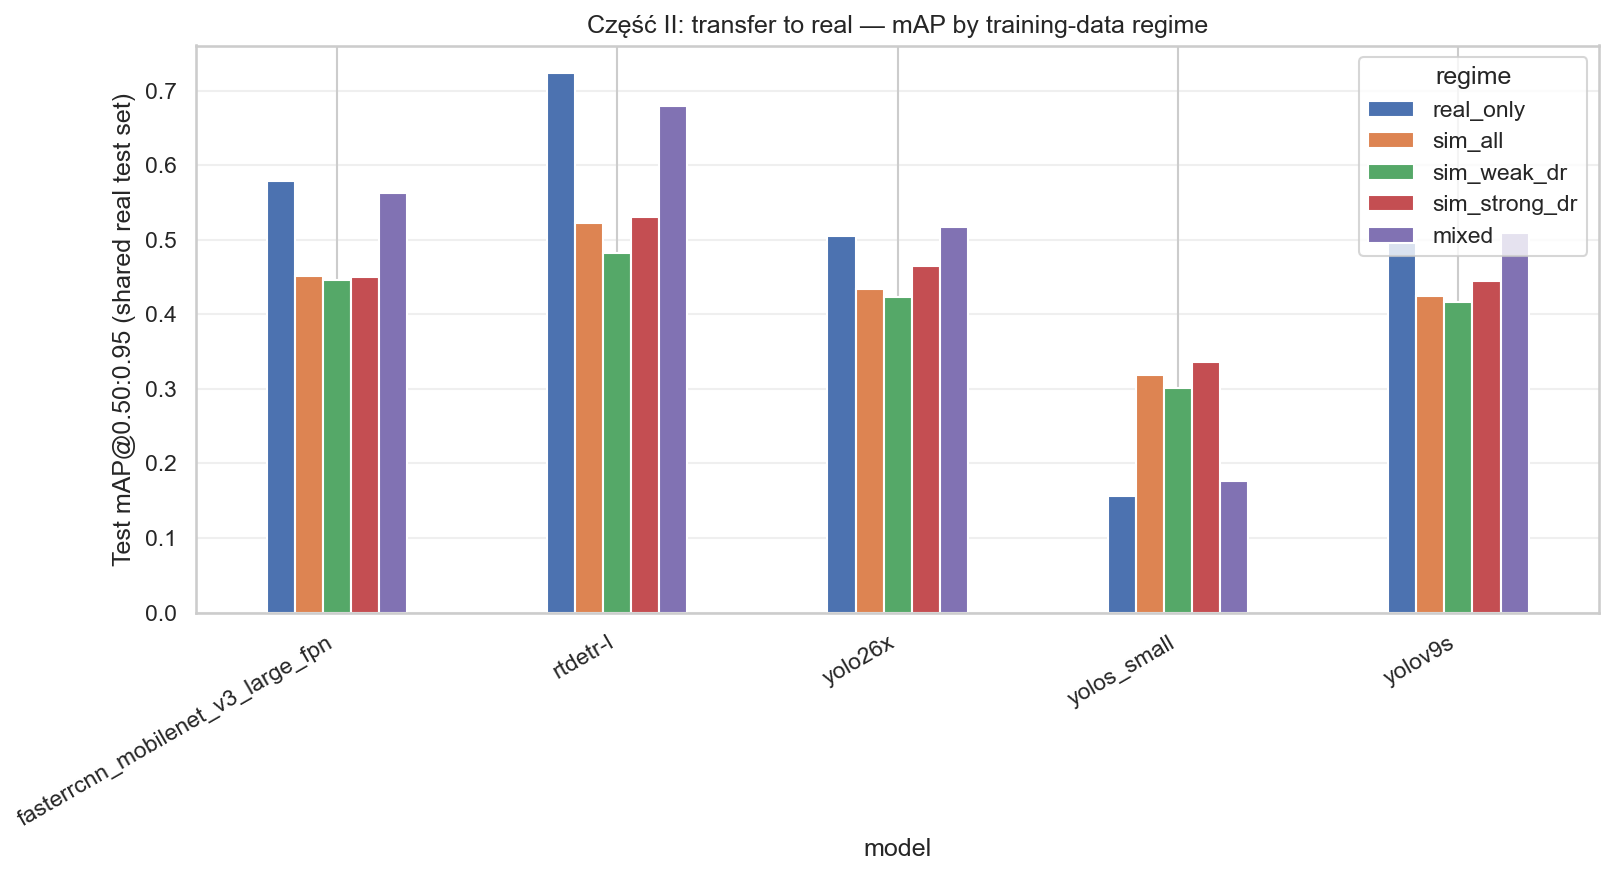

In [102]:
# ===================== Część II: mAP by data regime (grouped bar) =====================
import os
import pandas as pd
import matplotlib.pyplot as plt

pm = pd.read_csv(os.path.join(PROJECT_DIR, 'part2_master.csv'))
regime_order = [r for r in regimes.keys() if r in pm['regime'].unique()]

piv = pm.pivot_table(index='model', columns='regime', values='mAP_50_95').reindex(columns=regime_order)

ax = piv.plot(kind='bar', figsize=(11, 6))
ax.set_ylabel('Test mAP@0.50:0.95 (shared real test set)')
ax.set_xlabel('model')
ax.set_title('Część II: transfer to real — mAP by training-data regime')
ax.legend(title='regime')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

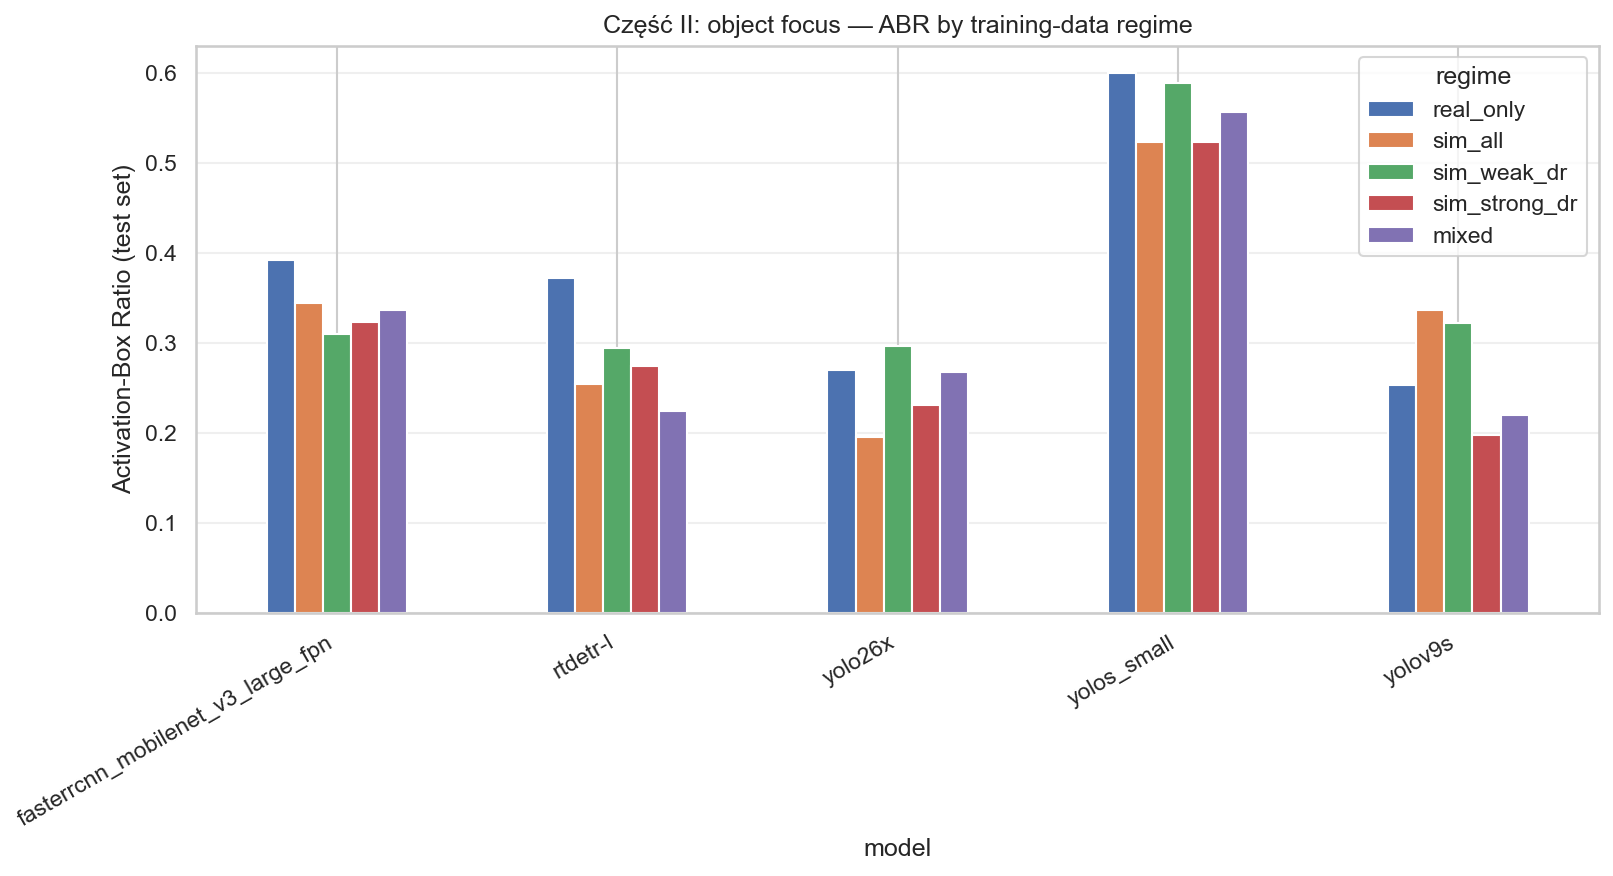

In [103]:
# ===================== Część II: ABR by data regime (grouped bar) =====================
import os
import pandas as pd
import matplotlib.pyplot as plt

pm = pd.read_csv(os.path.join(PROJECT_DIR, 'part2_master.csv'))
regime_order = [r for r in regimes.keys() if r in pm['regime'].unique()]

piv = pm.pivot_table(index='model', columns='regime', values='abr_mean').reindex(columns=regime_order)

ax = piv.plot(kind='bar', figsize=(11, 6))
ax.set_ylabel('Activation-Box Ratio (test set)')
ax.set_xlabel('model')
ax.set_title('Część II: object focus — ABR by training-data regime')
ax.legend(title='regime')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

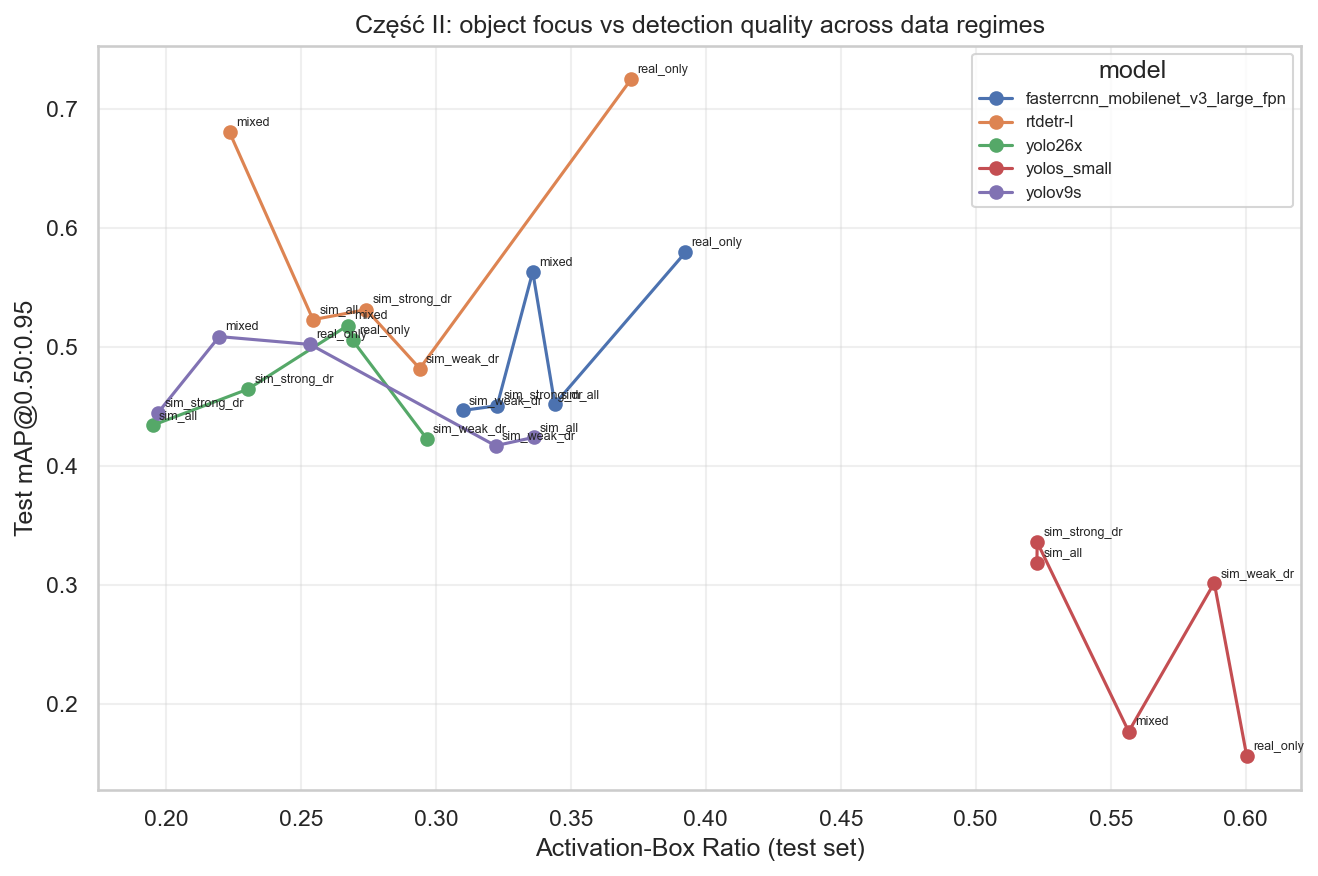

In [104]:
# ===================== Część II: mAP vs ABR, one track per model across regimes =====================
import os
import pandas as pd
import matplotlib.pyplot as plt

pm = pd.read_csv(os.path.join(PROJECT_DIR, 'part2_master.csv'))
fig, ax = plt.subplots(figsize=(9, 6))
for model, g in pm.groupby('model'):
    g = g.sort_values('abr_mean')
    ax.plot(g['abr_mean'], g['mAP_50_95'], marker='o', label=model)
    for _, r in g.iterrows():
        ax.annotate(r['regime'], (r['abr_mean'], r['mAP_50_95']),
                    fontsize=6, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Activation-Box Ratio (test set)')
ax.set_ylabel('Test mAP@0.50:0.95')
ax.set_title('Część II: object focus vs detection quality across data regimes')
ax.legend(title='model', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

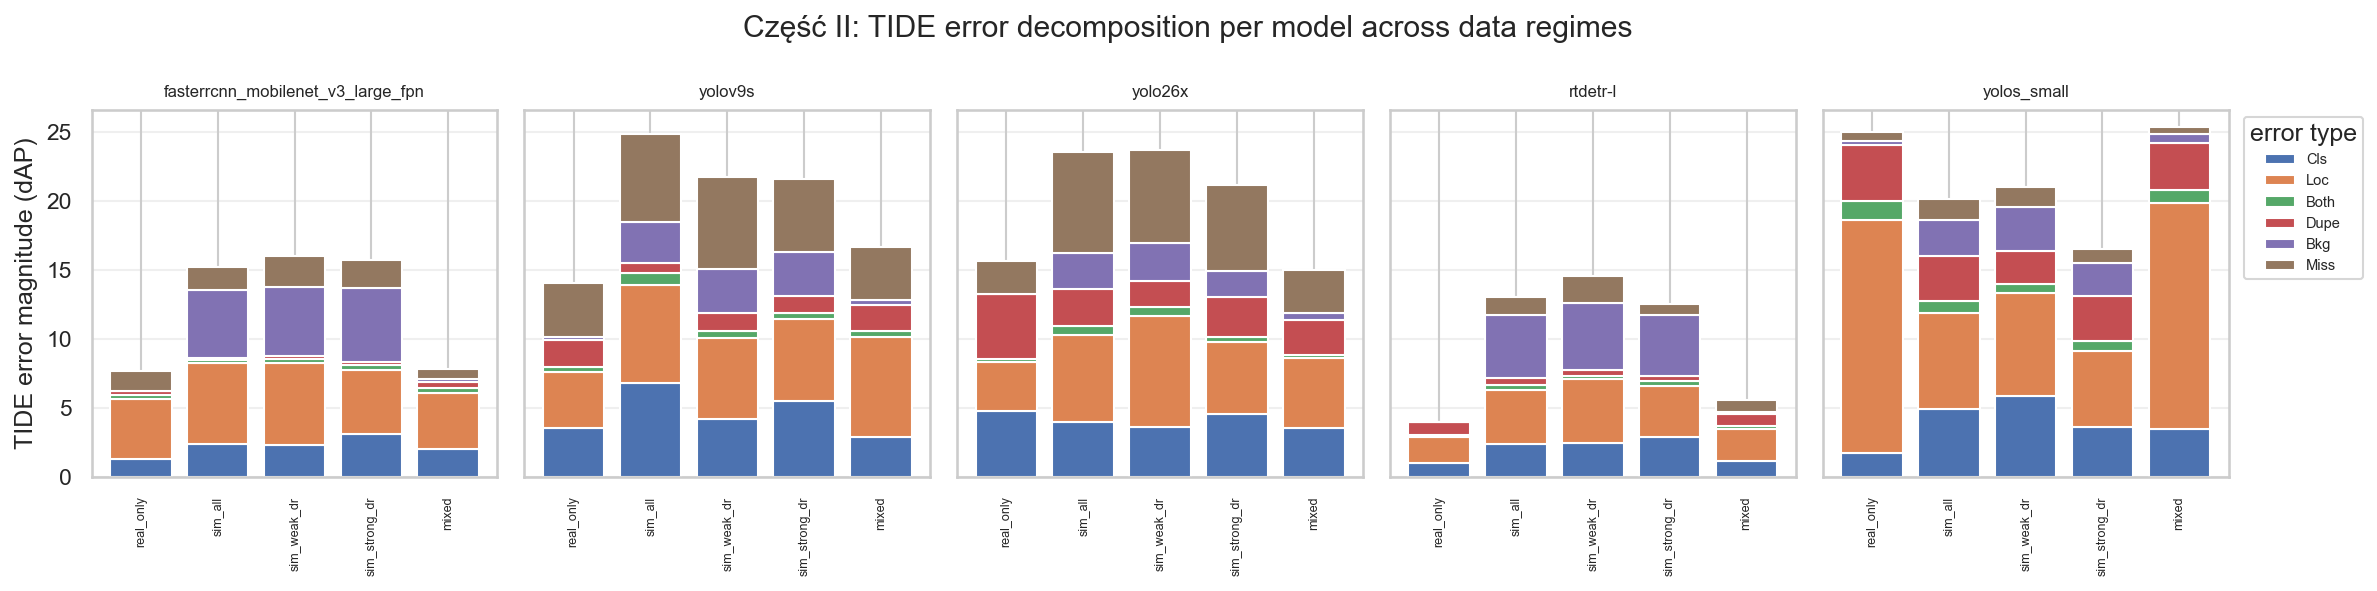

In [105]:
# ===================== Część II: TIDE error mix per model across regimes =====================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pm = pd.read_csv(os.path.join(PROJECT_DIR, 'part2_master.csv'))
TIDE_MAIN = ['Cls', 'Loc', 'Both', 'Dupe', 'Bkg', 'Miss']
present = [e for e in TIDE_MAIN if e in pm.columns]
regime_order = [r for r in regimes.keys() if r in pm['regime'].unique()]
models = list(pm['model'].unique())

n = len(models)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, model in zip(axes, models):
    g = pm[pm['model'] == model].set_index('regime').reindex(regime_order)
    bottom = np.zeros(len(g))
    for err in present:
        vals = g[err].fillna(0).to_numpy()
        ax.bar(range(len(g)), vals, bottom=bottom, label=err)
        bottom = bottom + vals
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(g.index, rotation=90, fontsize=6)
    ax.set_title(model, fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
axes[0].set_ylabel('TIDE error magnitude (dAP)')
axes[-1].legend(title='error type', fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('Część II: TIDE error decomposition per model across data regimes')
plt.tight_layout()
plt.show()

# Tensorboard Train/Val/Test Metrics Visualization

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir {PROJECT_DIR}

# Optional: archive PROJECT_DIR to Google Drive

All computation runs on local `/content` disk, which Colab wipes when the session ends. Run the archive cell to tar the whole `PROJECT_DIR` (models, runs, results, yolo dataset) into one file on Drive — a single fast sequential write instead of many slow small-file writes. Use the restore cell next session to bring it back.

Archive local PROJECT_DIR -> Google Drive (run when you want to persist a snapshot)


In [107]:
import os, tarfile, time

snapshot = os.path.join(DRIVE_DIR, f"project_snapshot_{time.strftime('%Y%m%d_%H%M%S')}.tar")
with tarfile.open(snapshot, 'w', dereference=True) as tar:  # dereference -> store real files, not symlinks
    tar.add(PROJECT_DIR, arcname=os.path.basename(PROJECT_DIR))